In [1]:
!git clone https://github.com/SAJLENDRAPANDEY/flyrank-ml-internship-starter.git

Cloning into 'flyrank-ml-internship-starter'...
remote: Enumerating objects: 229, done.
remote: Counting objects: 100% (144/144), done.
remote: Compressing objects: 100% (80/80), done.
remote: Total 229 (delta 104), reused 64 (delta 64), pack-reused 85 (from 1)
Receiving objects: 100% (229/229), 2.14 MiB | 4.30 MiB/s, done.
Resolving deltas: 100% (110/110), done.


In [2]:
import os

os.chdir("/content/flyrank-ml-internship-starter")

print(os.getcwd())

/content/flyrank-ml-internship-starter


In [3]:
import os

dataset_path = "data/raw/content_refresh_anonymized.csv"

print(os.path.exists(dataset_path))

True


In [4]:
import pandas as pd
import numpy as np

df = pd.read_csv(dataset_path)

In [5]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 30000
Columns: 44


In [6]:
df.head()

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


In [7]:
print(df.columns.tolist())

['content_id', 'client_id', 'search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier', 'position_tier', 'trend_direction', 'trend_pct']


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 44 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   content_id              30000 non-null  object 
 1   client_id               30000 non-null  object 
 2   search_volume           27532 non-null  float64
 3   competition             27532 non-null  float64
 4   competition_level       27390 non-null  object 
 5   cpc                     27532 non-null  float64
 6   content_type            30000 non-null  object 
 7   main_intent             27626 non-null  object 
 8   word_count              22301 non-null  float64
 9   char_count              22301 non-null  float64
 10  provider_used           8562 non-null   object 
 11  model_used              24267 non-null  object 
 12  impressions_90d         30000 non-null  int64  
 13  clicks_90d              30000 non-null  int64  
 14  pageviews_90d           30000 non-null

In [9]:
df.describe()

,search_volume,competition,cpc,word_count,char_count,impressions_90d,clicks_90d,pageviews_90d,sessions_90d,users_90d,...,sessions_prev_30d,content_age_days,age_tier_order,days_since_last_update,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,trend_pct
count,27532.000000,27532.000000,27532.000000,22301.000000,22301.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.00000,30000.000000,30000.000000,30000.000000,30000.00000,30000.000000,29875.000000,30000.000000,26612.000000
mean,158.882391,0.146954,0.485342,3107.760325,20665.277835,5200.366300,16.097333,49.942467,37.066633,35.937700,...,10.283000,256.16780,4.786533,46.098300,0.510733,16.34238,2.534520,18.212921,0.768196,-4.785969
std,1518.270825,0.285241,2.101560,1452.382598,10115.344042,16838.019547,75.076958,152.101430,107.069131,103.748185,...,42.578003,132.70793,0.790392,42.078709,3.279162,15.21679,8.310096,29.472768,7.429454,473.861780
min,0.000000,0.000000,0.000000,8.000000,40.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,0.000000,90.00000,3.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,-100.000000
25%,0.000000,0.000000,0.000000,2413.000000,15644.000000,81.000000,0.000000,2.000000,2.000000,2.000000,...,1.000000,132.00000,4.000000,20.000000,0.000000,6.20000,0.000000,0.000000,0.000000,-62.600000
50%,10.000000,0.000000,0.000000,2877.000000,19116.000000,731.000000,1.000000,8.000000,7.000000,7.000000,...,2.000000,236.00000,5.000000,20.000000,0.070000,10.80000,0.000000,5.000000,0.000000,-33.500000
75%,20.000000,0.130000,0.000000,3666.000000,24011.000000,3615.250000,7.000000,33.000000,27.000000,27.000000,...,7.000000,333.00000,5.000000,104.000000,0.290000,22.30000,1.350000,23.530000,0.000000,0.000000
max,74000.000000,1.000000,100.360000,9546.000000,111158.000000,517715.000000,4178.000000,5998.000000,4345.000000,4913.000000,...,4247.000000,564.00000,6.000000,373.000000,100.000000,245.00000,100.000000,300.000000,300.000000,44900.000000


In [10]:
missing = df.isnull().sum().sort_values(ascending=False)

missing[missing > 0]

,0
provider_used,21438
word_count,7699
char_count,7699
word_count_tier,7699
char_count_tier,7699
model_used,5733
trend_pct,3388
competition_level,2610
search_volume,2468
cpc,2468


In [11]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [12]:
print("Total rows:", len(df))
print("Unique content IDs:", df["content_id"].nunique())

Total rows: 30000
Unique content IDs: 30000


In [13]:
print("Unique clients:", df["client_id"].nunique())

Unique clients: 32


In [14]:
df[
    [
        "days_since_last_update",
        "impressions_90d",
        "ctr",
        "avg_position",
        "pageviews_90d",
        "sessions_90d",
        "engagement_rate"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
days_since_last_update,30000.0,46.098300,42.078709,1.0,20.0,20.00,104.00,373.0
impressions_90d,30000.0,5200.366300,16838.019547,1.0,81.0,731.00,3615.25,517715.0
ctr,30000.0,0.510733,3.279162,0.0,0.0,0.07,0.29,100.0
avg_position,30000.0,16.342380,15.216790,0.0,6.2,10.80,22.30,245.0
pageviews_90d,30000.0,49.942467,152.101430,0.0,2.0,8.00,33.00,5998.0
sessions_90d,30000.0,37.066633,107.069131,1.0,2.0,7.00,27.00,4345.0
engagement_rate,30000.0,2.534520,8.310096,0.0,0.0,0.00,1.35,100.0


In [15]:
print(
    "Rows with avg_position = 0:",
    (df["avg_position"] == 0).sum()
)

Rows with avg_position = 0: 1205


In [16]:
df["ctr"].describe()

,ctr
count,30000.000000
mean,0.510733
std,3.279162
min,0.000000
25%,0.000000
50%,0.070000
75%,0.290000
max,100.000000


In [17]:
print("CTR median:", df["ctr"].median())

CTR median: 0.07


In [18]:
df["impressions_90d"].describe()

,impressions_90d
count,30000.000000
mean,5200.366300
std,16838.019547
min,1.000000
25%,81.000000
50%,731.000000
75%,3615.250000
max,517715.000000


In [19]:
print(
    "Impressions median:",
    df["impressions_90d"].median()
)

Impressions median: 731.0


In [20]:
df["days_since_last_update"].describe()

,days_since_last_update
count,30000.000000
mean,46.098300
std,42.078709
min,1.000000
25%,20.000000
50%,20.000000
75%,104.000000
max,373.000000


In [21]:
print(
    "Median days since update:",
    df["days_since_last_update"].median()
)

Median days since update: 20.0


EDA


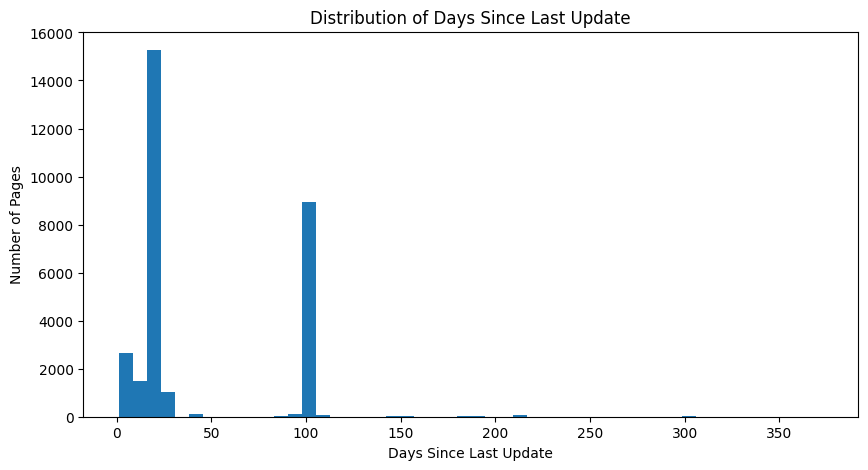

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(
    df["days_since_last_update"],
    bins=50
)

plt.xlabel("Days Since Last Update")
plt.ylabel("Number of Pages")
plt.title("Distribution of Days Since Last Update")

plt.show()

In [23]:
df["update_age_bucket"] = pd.cut(
    df["days_since_last_update"],
    bins=[-1, 30, 90, 180, 365, float("inf")],
    labels=[
        "0-30",
        "31-90",
        "91-180",
        "181-365",
        "365+"
    ]
)

age_summary = (
    df["update_age_bucket"]
    .value_counts()
    .sort_index()
)

print(age_summary)

update_age_bucket
0-30       20480
31-90        175
91-180      9171
181-365      169
365+           5
Name: count, dtype: int64


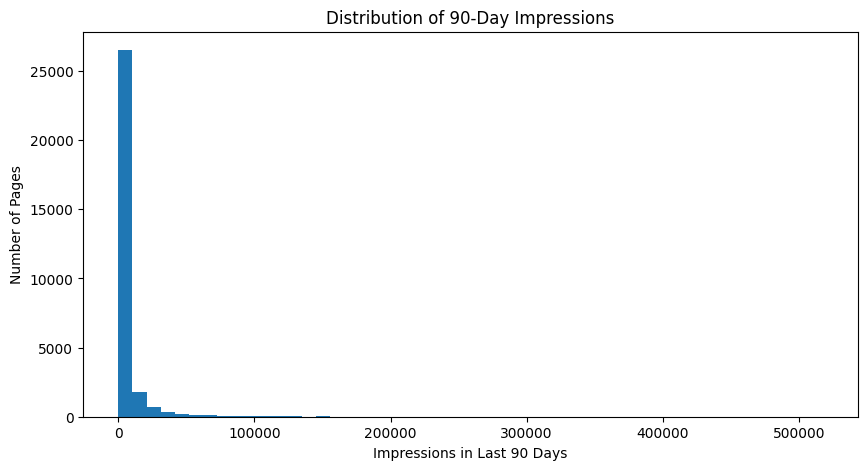

In [24]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["impressions_90d"],
    bins=50
)

plt.xlabel("Impressions in Last 90 Days")
plt.ylabel("Number of Pages")
plt.title("Distribution of 90-Day Impressions")

plt.show()

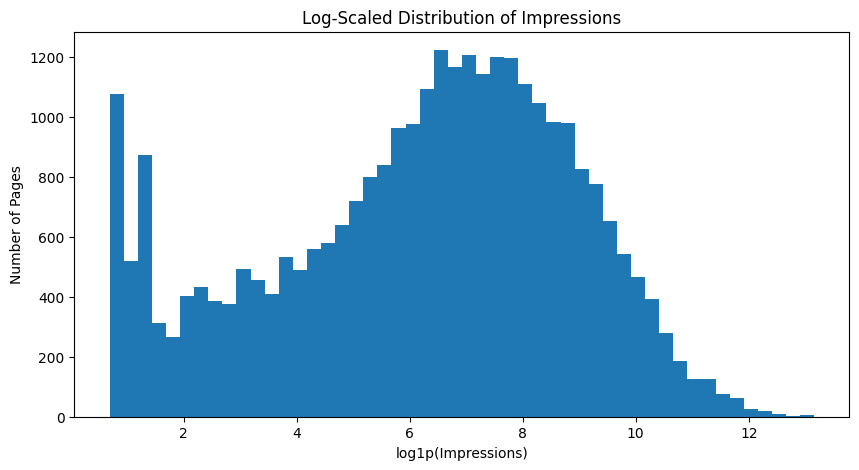

In [25]:
plt.figure(figsize=(10, 5))

plt.hist(
    np.log1p(df["impressions_90d"]),
    bins=50
)

plt.xlabel("log1p(Impressions)")
plt.ylabel("Number of Pages")
plt.title("Log-Scaled Distribution of Impressions")

plt.show()

In [26]:
df["impression_bucket"] = pd.cut(
    df["impressions_90d"],
    bins=[-1, 100, 500, 1000, 3000, 10000, float("inf")],
    labels=[
        "0-100",
        "101-500",
        "501-1000",
        "1001-3000",
        "3001-10000",
        "10000+"
    ]
)

print(
    df["impression_bucket"]
    .value_counts()
    .sort_index()
)

impression_bucket
0-100         8006
101-500       5279
501-1000      3206
1001-3000     5226
3001-10000    4681
10000+        3602
Name: count, dtype: int64


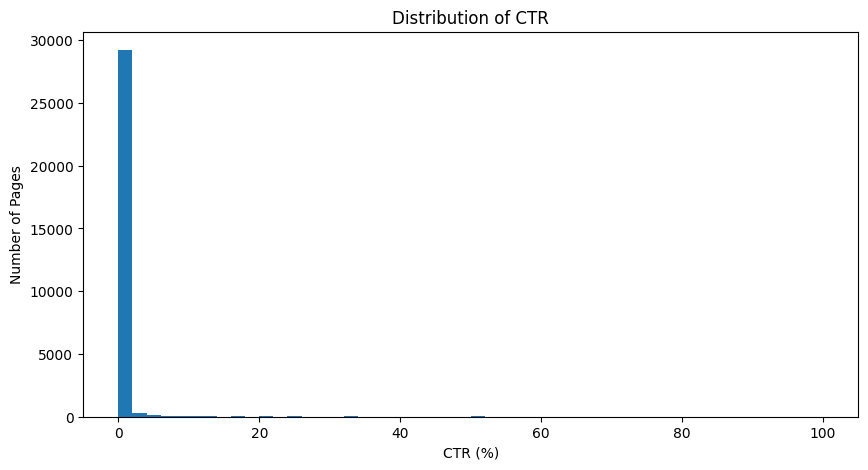

In [27]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["ctr"],
    bins=50
)

plt.xlabel("CTR (%)")
plt.ylabel("Number of Pages")
plt.title("Distribution of CTR")

plt.show()

In [28]:
df["ctr_bucket"] = pd.cut(
    df["ctr"],
    bins=[-float("inf"), 0.05, 0.1, 0.5, 1, 2, float("inf")],
    labels=[
        "<0.05%",
        "0.05-0.1%",
        "0.1-0.5%",
        "0.5-1%",
        "1-2%",
        "2%+"
    ]
)

print(
    df["ctr_bucket"]
    .value_counts()
    .sort_index()
)

ctr_bucket
<0.05%       14419
0.05-0.1%     2077
0.1-0.5%      9355
0.5-1%        2460
1-2%           915
2%+            774
Name: count, dtype: int64


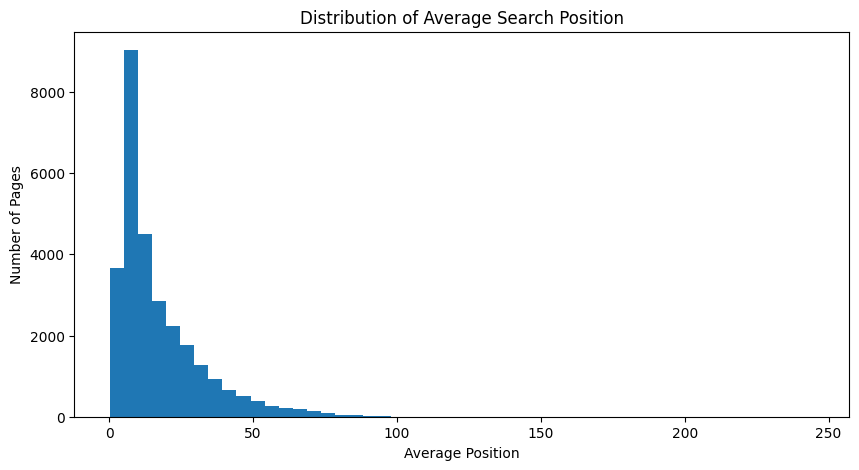

In [29]:
plt.figure(figsize=(10, 5))

position_data = df.loc[
    df["avg_position"] > 0,
    "avg_position"
]

plt.hist(
    position_data,
    bins=50
)

plt.xlabel("Average Position")
plt.ylabel("Number of Pages")
plt.title("Distribution of Average Search Position")

plt.show()

In [30]:
old_pages = df[
    df["days_since_last_update"] >= 90
]

print("Pages >= 90 days old:", len(old_pages))

high_visibility_old = df[
    (df["days_since_last_update"] >= 90) &
    (df["impressions_90d"] >= df["impressions_90d"].median())
]

print(
    "Old + above-median visibility:",
    len(high_visibility_old)
)

high_visibility_old[
    [
        "content_id",
        "days_since_last_update",
        "impressions_90d",
        "ctr",
        "avg_position"
    ]
].head(20)

Pages >= 90 days old: 9345
Old + above-median visibility: 5992


,content_id,days_since_last_update,impressions_90d,ctr,avg_position
9,content_c27558df2b0c,104,1240,0.16,4.9
10,content_d8ee6cc6d642,104,20919,1.55,2.2
12,content_42fb2cad9ecf,104,7228,1.76,5.6
16,content_78bd1d4a1d4d,104,13848,0.15,8.9
24,content_0e23e310d404,104,29541,0.27,4.1
27,content_7ea135180dd9,104,1197,0.17,8.1
35,content_1a28b25c7128,104,19790,0.03,24.8
38,content_dbe82879a406,104,26457,0.12,33.3
40,content_4df0b7207fe3,151,1700,1.65,49.6
46,content_c59d46264834,104,1193,0.08,6.1


In [31]:
freshness_analysis = (
    df.groupby("update_age_bucket")
      .agg(
          pages=("content_id", "count"),
          median_impressions=("impressions_90d", "median"),
          median_ctr=("ctr", "median"),
          median_users=("users_90d", "median")
      )
      .reset_index()
)

freshness_analysis

/tmp/ipykernel_1250/2959005629.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("update_age_bucket")


,update_age_bucket,pages,median_impressions,median_ctr,median_users
0,0-30,20480,470.0,0.04,5.0
1,31-90,175,510.0,0.00,9.0
2,91-180,9171,1692.0,0.10,16.0
3,181-365,169,16.0,0.00,2.0
4,365+,5,2.0,0.00,1.0


In [32]:
visibility_analysis = (
    df.groupby("impression_bucket")
      .agg(
          pages=("content_id", "count"),
          median_ctr=("ctr", "median"),
          median_position=("avg_position", "median"),
          median_users=("users_90d", "median")
      )
      .reset_index()
)

visibility_analysis

/tmp/ipykernel_1250/1766772628.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("impression_bucket")


,impression_bucket,pages,median_ctr,median_position,median_users
0,0-100,8006,0.00,7.5,2.0
1,101-500,5279,0.00,16.3,4.0
2,501-1000,3206,0.12,15.1,6.0
3,1001-3000,5226,0.14,12.6,11.0
4,3001-10000,4681,0.20,9.9,28.0
5,10000+,3602,0.23,7.5,94.0


In [33]:
analysis = df[
    (df["days_since_last_update"] >= 90) &
    (df["impressions_90d"] >= df["impressions_90d"].median())
].copy()

analysis[
    [
        "days_since_last_update",
        "impressions_90d",
        "users_90d",
        "ctr",
        "avg_position"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
days_since_last_update,5992.0,104.293391,5.672769,92.0,104.00,104.00,104.00,301.00
impressions_90d,5992.0,11355.103304,23690.674603,731.0,1793.75,4115.00,11090.00,517715.00
users_90d,5992.0,93.769693,161.046271,1.0,11.75,37.00,112.00,4153.00
ctr,5992.0,0.259214,0.314275,0.0,0.07,0.16,0.34,3.56
avg_position,5992.0,16.587834,12.688030,0.2,6.20,12.80,24.40,85.50


In [34]:
position_ctr = df[df["avg_position"] > 0].copy()

position_ctr["position_bucket"] = pd.cut(
    position_ctr["avg_position"],
    bins=[0, 3, 10, 20, 50, float("inf")],
    labels=["Top 3", "4-10", "11-20", "21-50", "50+"]
)

position_benchmark = (
    position_ctr
    .groupby("position_bucket", observed=True)["ctr"]
    .median()
)

print(position_benchmark)

position_bucket
Top 3    0.00
4-10     0.16
11-20    0.10
21-50    0.03
50+      0.00
Name: ctr, dtype: float64


In [35]:
position_ctr["expected_ctr"] = (
    position_ctr["position_bucket"]
    .map(position_benchmark)
    .astype(float)
)

In [36]:
position_ctr["ctr_gap"] = (
    position_ctr["expected_ctr"] - position_ctr["ctr"]
)

In [37]:
position_ctr[
    [
        "content_id",
        "avg_position",
        "ctr",
        "expected_ctr",
        "ctr_gap"
    ]
].sort_values(
    "ctr_gap",
    ascending=False
).head(20)

,content_id,avg_position,ctr,expected_ctr,ctr_gap
6,content_9a34b442b552,7.0,0.0,0.16,0.16
29977,content_c87291853cab,8.2,0.0,0.16,0.16
18394,content_5f5a9c0c10f3,6.3,0.0,0.16,0.16
18398,content_75db27ddb2a5,10.0,0.0,0.16,0.16
18400,content_d971ed6a14fb,7.4,0.0,0.16,0.16
18405,content_31faa2bf193e,6.0,0.0,0.16,0.16
48,content_326fa2fa449f,8.3,0.0,0.16,0.16
51,content_d8a23b5e10c5,7.5,0.0,0.16,0.16
25,content_033ae3e7aecf,7.2,0.0,0.16,0.16
18381,content_ca8eb8fdc6fa,6.7,0.0,0.16,0.16


In [38]:
candidates = position_ctr[
    (position_ctr["days_since_last_update"] >= 90) &
    (position_ctr["impressions_90d"] >= 1000) &
    (position_ctr["ctr_gap"] > 0)
].copy()

print("Candidate pages:", len(candidates))

Candidate pages: 1450


In [39]:
candidates[
    [
        "days_since_last_update",
        "impressions_90d",
        "users_90d",
        "ctr",
        "avg_position",
        "ctr_gap"
    ]
].describe()

,days_since_last_update,impressions_90d,users_90d,ctr,avg_position,ctr_gap
count,1450.000000,1450.000000,1450.000000,1450.000000,1450.000000,1450.000000
mean,104.134483,10340.801379,43.085517,0.055600,14.142414,0.063697
std,3.364325,24710.037819,70.828243,0.048091,11.323567,0.043645
min,92.000000,1003.000000,1.000000,0.000000,3.100000,0.010000
25%,104.000000,1712.750000,7.000000,0.000000,6.400000,0.030000
50%,104.000000,3372.500000,19.000000,0.050000,9.000000,0.050000
75%,104.000000,8360.500000,48.750000,0.090000,18.075000,0.100000
max,194.000000,517715.000000,774.000000,0.150000,49.800000,0.160000


In [40]:
import numpy as np
import pandas as pd

# Make a clean copy
ranked = candidates.copy()

# -----------------------------
# 1. Freshness score
# -----------------------------
ranked["freshness_score"] = np.select(
    [
        ranked["days_since_last_update"] >= 180,
        ranked["days_since_last_update"] >= 120,
        ranked["days_since_last_update"] >= 90
    ],
    [
        1.0,
        0.7,
        0.4
    ],
    default=0.0
)

# -----------------------------
# 2. Visibility score
# log transform prevents
# huge-impression pages dominating
# -----------------------------
log_imp = np.log1p(ranked["impressions_90d"])

ranked["visibility_score"] = (
    (log_imp - log_imp.min()) /
    (log_imp.max() - log_imp.min())
)

# -----------------------------
# 3. CTR opportunity score
# -----------------------------
ranked["ctr_opportunity_score"] = (
    (ranked["ctr_gap"] - ranked["ctr_gap"].min()) /
    (ranked["ctr_gap"].max() - ranked["ctr_gap"].min())
)

# -----------------------------
# 4. Final priority score
# -----------------------------
ranked["priority_score"] = (
    0.30 * ranked["freshness_score"]
    + 0.40 * ranked["visibility_score"]
    + 0.30 * ranked["ctr_opportunity_score"]
)

ranked = ranked.sort_values(
    "priority_score",
    ascending=False
).reset_index(drop=True)

ranked["rank"] = ranked.index + 1

ranked[
    [
        "rank",
        "content_id",
        "days_since_last_update",
        "impressions_90d",
        "users_90d",
        "ctr",
        "avg_position",
        "ctr_gap",
        "priority_score"
    ]
].head(20)

,rank,content_id,days_since_last_update,impressions_90d,users_90d,ctr,avg_position,ctr_gap,priority_score
0,1,content_c8e9d6ab9013,104,208678,6,0.00,9.7,0.16,0.761805
1,2,content_36ff89c8214e,104,295097,232,0.05,7.3,0.11,0.683998
2,3,content_c1fe78bc4e37,104,134055,161,0.03,7.5,0.13,0.673462
3,4,content_b115f7c74779,104,123469,42,0.03,8.0,0.13,0.668194
4,5,content_d0cc5baa4995,104,83651,68,0.03,6.6,0.13,0.643258
5,6,content_d07ea098353c,104,63366,29,0.03,9.4,0.13,0.625471
6,7,content_91652435f57a,104,159590,100,0.06,7.8,0.10,0.624629
7,8,content_9c8299b55f3c,104,54783,31,0.03,8.5,0.13,0.616149
8,9,content_896bf2cc27b7,104,66359,64,0.04,4.9,0.12,0.608427
9,10,content_c9eeaab4031e,104,34100,17,0.02,6.2,0.14,0.605786


In [41]:
def get_reason(row):

    reasons = []

    if row["days_since_last_update"] >= 180:
        reasons.append("VERY_STALE")

    elif row["days_since_last_update"] >= 90:
        reasons.append("STALE")

    if row["impressions_90d"] >= 10000:
        reasons.append("HIGH_VISIBILITY")

    elif row["impressions_90d"] >= 3000:
        reasons.append("MEANINGFUL_VISIBILITY")

    if row["ctr_gap"] >= 0.10:
        reasons.append("HIGH_CTR_OPPORTUNITY")

    elif row["ctr_gap"] >= 0.05:
        reasons.append("CTR_OPPORTUNITY")

    return " | ".join(reasons)


ranked["reason_code"] = ranked.apply(
    get_reason,
    axis=1
)

ranked.head(20)[
    [
        "rank",
        "content_id",
        "priority_score",
        "reason_code"
    ]
]

,rank,content_id,priority_score,reason_code
0,1,content_c8e9d6ab9013,0.761805,STALE | HIGH_VISIBILITY | HIGH_CTR_OPPORTUNITY
1,2,content_36ff89c8214e,0.683998,STALE | HIGH_VISIBILITY | HIGH_CTR_OPPORTUNITY
2,3,content_c1fe78bc4e37,0.673462,STALE | HIGH_VISIBILITY | HIGH_CTR_OPPORTUNITY
3,4,content_b115f7c74779,0.668194,STALE | HIGH_VISIBILITY | HIGH_CTR_OPPORTUNITY
4,5,content_d0cc5baa4995,0.643258,STALE | HIGH_VISIBILITY | HIGH_CTR_OPPORTUNITY
5,6,content_d07ea098353c,0.625471,STALE | HIGH_VISIBILITY | HIGH_CTR_OPPORTUNITY
6,7,content_91652435f57a,0.624629,STALE | HIGH_VISIBILITY | HIGH_CTR_OPPORTUNITY
7,8,content_9c8299b55f3c,0.616149,STALE | HIGH_VISIBILITY | HIGH_CTR_OPPORTUNITY
8,9,content_896bf2cc27b7,0.608427,STALE | HIGH_VISIBILITY | HIGH_CTR_OPPORTUNITY
9,10,content_c9eeaab4031e,0.605786,STALE | HIGH_VISIBILITY | HIGH_CTR_OPPORTUNITY


In [42]:
def get_action(score):

    if score >= 0.70:
        return "High Priority Review"

    elif score >= 0.45:
        return "Review"

    else:
        return "Monitor"


ranked["action"] = ranked["priority_score"].apply(
    get_action
)

ranked.head(20)[
    [
        "rank",
        "content_id",
        "priority_score",
        "reason_code",
        "action"
    ]
]

,rank,content_id,priority_score,reason_code,action
0,1,content_c8e9d6ab9013,0.761805,STALE | HIGH_VISIBILITY | HIGH_CTR_OPPORTUNITY,High Priority Review
1,2,content_36ff89c8214e,0.683998,STALE | HIGH_VISIBILITY | HIGH_CTR_OPPORTUNITY,Review
2,3,content_c1fe78bc4e37,0.673462,STALE | HIGH_VISIBILITY | HIGH_CTR_OPPORTUNITY,Review
3,4,content_b115f7c74779,0.668194,STALE | HIGH_VISIBILITY | HIGH_CTR_OPPORTUNITY,Review
4,5,content_d0cc5baa4995,0.643258,STALE | HIGH_VISIBILITY | HIGH_CTR_OPPORTUNITY,Review
5,6,content_d07ea098353c,0.625471,STALE | HIGH_VISIBILITY | HIGH_CTR_OPPORTUNITY,Review
6,7,content_91652435f57a,0.624629,STALE | HIGH_VISIBILITY | HIGH_CTR_OPPORTUNITY,Review
7,8,content_9c8299b55f3c,0.616149,STALE | HIGH_VISIBILITY | HIGH_CTR_OPPORTUNITY,Review
8,9,content_896bf2cc27b7,0.608427,STALE | HIGH_VISIBILITY | HIGH_CTR_OPPORTUNITY,Review
9,10,content_c9eeaab4031e,0.605786,STALE | HIGH_VISIBILITY | HIGH_CTR_OPPORTUNITY,Review


In [43]:
top20 = ranked.head(20).copy()

top20[
    [
        "rank",
        "content_id",
        "priority_score",
        "action",
        "reason_code",
        "days_since_last_update",
        "impressions_90d",
        "users_90d",
        "ctr",
        "avg_position",
        "ctr_gap"
    ]
]

,rank,content_id,priority_score,action,reason_code,days_since_last_update,impressions_90d,users_90d,ctr,avg_position,ctr_gap
0,1,content_c8e9d6ab9013,0.761805,High Priority Review,STALE | HIGH_VISIBILITY | HIGH_CTR_OPPORTUNITY,104,208678,6,0.00,9.7,0.16
1,2,content_36ff89c8214e,0.683998,Review,STALE | HIGH_VISIBILITY | HIGH_CTR_OPPORTUNITY,104,295097,232,0.05,7.3,0.11
2,3,content_c1fe78bc4e37,0.673462,Review,STALE | HIGH_VISIBILITY | HIGH_CTR_OPPORTUNITY,104,134055,161,0.03,7.5,0.13
3,4,content_b115f7c74779,0.668194,Review,STALE | HIGH_VISIBILITY | HIGH_CTR_OPPORTUNITY,104,123469,42,0.03,8.0,0.13
4,5,content_d0cc5baa4995,0.643258,Review,STALE | HIGH_VISIBILITY | HIGH_CTR_OPPORTUNITY,104,83651,68,0.03,6.6,0.13
5,6,content_d07ea098353c,0.625471,Review,STALE | HIGH_VISIBILITY | HIGH_CTR_OPPORTUNITY,104,63366,29,0.03,9.4,0.13
6,7,content_91652435f57a,0.624629,Review,STALE | HIGH_VISIBILITY | HIGH_CTR_OPPORTUNITY,104,159590,100,0.06,7.8,0.10
7,8,content_9c8299b55f3c,0.616149,Review,STALE | HIGH_VISIBILITY | HIGH_CTR_OPPORTUNITY,104,54783,31,0.03,8.5,0.13
8,9,content_896bf2cc27b7,0.608427,Review,STALE | HIGH_VISIBILITY | HIGH_CTR_OPPORTUNITY,104,66359,64,0.04,4.9,0.12
9,10,content_c9eeaab4031e,0.605786,Review,STALE | HIGH_VISIBILITY | HIGH_CTR_OPPORTUNITY,104,34100,17,0.02,6.2,0.14


In [44]:
import os

os.makedirs("work/outputs", exist_ok=True)

ranked.to_csv(
    "work/outputs/baseline_action_score.csv",
    index=False
)

print("Saved successfully.")

Saved successfully.


In [45]:
!pip -q install datasets huggingface_hub duckdb pandas pyarrow

In [46]:
from google.colab import userdata
from huggingface_hub import login

HF_TOKEN = userdata.get("HF_TOKEN")

if HF_TOKEN is None:
    raise ValueError("HF_TOKEN Colab Not set.")

login(HF_TOKEN)

In [47]:
import duckdb

con = duckdb.connect()

con.execute(f"""
CREATE SECRET (
    TYPE huggingface,
    TOKEN '{HF_TOKEN}'
)
""")

rel = "hf://datasets/FlyRank/internship-warehouse"

print("DuckDB + Hugging Face connection ready.")

DuckDB + Hugging Face connection ready.


In [48]:
con.sql(f"""
SELECT COUNT(*)
FROM read_parquet(
    '{rel}/fact_content_daily_performance/**/*.parquet'
)
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌──────────────┐
│ count_star() │
│    int64     │
├──────────────┤
│     78835655 │
└──────────────┘

In [49]:
con.sql(f"""
SELECT
    MIN(report_date) AS first_date,
    MAX(report_date) AS last_date,
    COUNT(*) AS total_rows
FROM read_parquet(
    '{rel}/fact_content_daily_performance/**/*.parquet'
)
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌────────────┬────────────┬────────────┐
│ first_date │ last_date  │ total_rows │
│    date    │    date    │   int64    │
├────────────┼────────────┼────────────┤
│ 2025-01-27 │ 2026-06-30 │   78835655 │
└────────────┴────────────┴────────────┘

In [50]:
con.sql(f"""
SELECT *
FROM read_parquet(
    '{rel}/fact_content_daily_performance/**/*.parquet'
)
LIMIT 5
""")

┌─────────────┬─────────────────────────┬──────────────────────────┬────────────────┬────────────────┬────────────────────┬────────────────────┬─────────────────┬────────────┬──────────────────┬────────────────────┬───────────────┬──────────────┬───────────┬──────────────────────┬──────────────────────────┬──────────────────┬─────────────────┬───────────────────┬─────────────────┬───────────────┬─────────────┬────────────┬───────────────┬───────────┬────────────┬───────────┬─────────┬──────────┬───────────────┬─────────┐
│ report_date │     client_hash_id      │     content_hash_id      │ client_has_gsc │ client_has_ga4 │ gsc_data_available │ ga4_data_available │ gsc_impressions │ gsc_clicks │ gsc_sum_position │  gsc_avg_position  │ ga4_pageviews │ ga4_sessions │ ga4_users │ ga4_engaged_sessions │ ga4_total_engagement_sec │ sessions_organic │ sessions_direct │ sessions_referral │ sessions_social │ sessions_paid │ sessions_ai │ ai_chatgpt │ ai_perplexity │ ai_gemini │ ai_copilot │ ai_cl

In [51]:
con.sql(f"""
SELECT
    client_hash_id,
    content_hash_id,
    report_date,
    COUNT(*) AS row_count
FROM read_parquet(
    '{rel}/fact_content_daily_performance/**/*.parquet'
)
GROUP BY
    client_hash_id,
    content_hash_id,
    report_date
HAVING COUNT(*) > 1
LIMIT 5
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌─────────────────────────┬──────────────────────────┬─────────────┬───────────┐
│     client_hash_id      │     content_hash_id      │ report_date │ row_count │
│         varchar         │         varchar          │    date     │   int64   │
├─────────────────────────┼──────────────────────────┼─────────────┼───────────┤
│ client_06d356715a8ff3b6 │ content_03a8b5950a52518a │ 2026-06-13  │         2 │
│ client_810019792c9b8efc │ content_26b4ce630106d689 │ 2026-06-16  │         2 │
│ client_06d356715a8ff3b6 │ content_f5a0c77c1826b467 │ 2026-06-16  │         2 │
│ client_b77d0d5f08f05e64 │ content_6b6a532cb09428b2 │ 2026-06-20  │         2 │
│ client_b77d0d5f08f05e64 │ content_52a40d3e61e4e4cc │ 2026-06-20  │         2 │
└─────────────────────────┴──────────────────────────┴─────────────┴───────────┘

In [52]:
sample_rel = f"{rel}/fact_content_daily_performance_sample.parquet"

con.sql(f"""
SELECT
    COUNT(*) AS total_rows,
    MIN(report_date) AS first_date,
    MAX(report_date) AS last_date
FROM read_parquet('{sample_rel}')
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌────────────┬────────────┬────────────┐
│ total_rows │ first_date │ last_date  │
│   int64    │    date    │    date    │
├────────────┼────────────┼────────────┤
│   11694072 │ 2026-06-01 │ 2026-06-30 │
└────────────┴────────────┴────────────┘

In [53]:
con.sql(f"""
SELECT *
FROM read_parquet(
    '{rel}/dim_content.parquet'
)
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌─────────────────────────┬──────────────────────────┬──────────────────────────┬──────────────────────┬────────────────────┬─────────────────────┬────────────────┬──────────────────────┬──────────────────────┬─────────────────┬───────────────┬─────────────┬───────────────────┬────────┬───────────────┬───────────┬────────────────┬──────────────────────┬─────────────────────────┬────────────────────────┬────────────┬────────────┬─────────────────────┬────────────────────────────┬──────────────┬────────────┐
│     client_hash_id      │     content_hash_id      │     keyword_hash_id      │     url_hash_id      │ keyword_char_count │ keyword_token_count │ url_char_count │ content_created_date │ content_updated_date │  content_type   │ search_volume │ competition │ competition_level │  cpc   │  main_intent  │ backlinks │ category_count │ keyword_created_date │      provider_used      │       model_used       │ char_count │ word_count │ last_optimized_date │ optimization_eligible_date │ is_p

In [54]:
content_df = con.sql(f"""
SELECT *
FROM read_parquet(
    '{rel}/dim_content.parquet'
)
LIMIT 100
""").df()

print(content_df.columns.tolist())

['client_hash_id', 'content_hash_id', 'keyword_hash_id', 'url_hash_id', 'keyword_char_count', 'keyword_token_count', 'url_char_count', 'content_created_date', 'content_updated_date', 'content_type', 'search_volume', 'competition', 'competition_level', 'cpc', 'main_intent', 'backlinks', 'category_count', 'keyword_created_date', 'provider_used', 'model_used', 'char_count', 'word_count', 'last_optimized_date', 'optimization_eligible_date', 'is_published', 'is_deleted']


In [55]:
may_june = con.sql(f"""
SELECT
    client_hash_id,
    content_hash_id,
    report_date,
    gsc_impressions,
    gsc_clicks,
    gsc_avg_position,
    ga4_users,
    ga4_sessions
FROM read_parquet(
    '{rel}/fact_content_daily_performance/month=2026-0[56]/*.parquet'
)
""").df()

print("Rows:", len(may_june))
print(may_june.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rows: 23381448
            client_hash_id           content_hash_id report_date  \
0  client_3ffa76342f366962  content_4eb35f25cf28b104  2026-05-01   
1  client_3ffa76342f366962  content_5e4bf89ca5706ca2  2026-05-01   
2  client_3ffa76342f366962  content_2dd03169b60f7a43  2026-05-01   
3  client_3ffa76342f366962  content_93ea5d35d707f873  2026-05-01   
4  client_3ffa76342f366962  content_c000c4c9e218328b  2026-05-01   

   gsc_impressions  gsc_clicks  gsc_avg_position  ga4_users  ga4_sessions  
0                0           0               NaN          0             0  
1                0           0               NaN          0             0  
2                0           0               NaN          0             0  
3                0           0               NaN          0             0  
4                0           0               NaN          0             0  


In [56]:
may = may_june[
    may_june["report_date"].dt.month == 5
].copy()

may_features = (
    may
    .groupby(["client_hash_id", "content_hash_id"])
    .agg(
        impressions_30d=("gsc_impressions", "sum"),
        clicks_30d=("gsc_clicks", "sum"),
        users_30d=("ga4_users", "sum"),
        sessions_30d=("ga4_sessions", "sum"),
        avg_position=("gsc_avg_position", "mean")
    )
    .reset_index()
)

may_features["ctr"] = (
    may_features["clicks_30d"]
    / may_features["impressions_30d"].replace(0, np.nan)
    * 100
)

may_features["ctr"] = may_features["ctr"].fillna(0)

print(may_features.shape)
may_features.head()

(389153, 8)


,client_hash_id,content_hash_id,impressions_30d,clicks_30d,users_30d,sessions_30d,avg_position,ctr
0,client_04660893ae39614a,content_004de9653278b5a4,0,0,0,0,NaN,0.0
1,client_04660893ae39614a,content_01410f2556c327ac,0,0,0,0,NaN,0.0
2,client_04660893ae39614a,content_01efa71faea45dcc,0,0,0,0,NaN,0.0
3,client_04660893ae39614a,content_01fc9e2e57898b55,0,0,0,0,NaN,0.0
4,client_04660893ae39614a,content_0212158fa61c5fcb,0,0,0,0,NaN,0.0


In [57]:
content_meta = con.sql(f"""
SELECT
    client_hash_id,
    content_hash_id,
    content_updated_date,
    content_created_date,
    content_type,
    search_volume,
    competition,
    main_intent
FROM read_parquet(
    '{rel}/dim_content.parquet'
)
WHERE is_deleted = FALSE
""").df()

content_meta["content_updated_date"] = pd.to_datetime(
    content_meta["content_updated_date"]
)

content_meta.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,client_hash_id,content_hash_id,content_updated_date,content_created_date,content_type,search_volume,competition,main_intent
0,client_04660893ae39614a,content_004de9653278b5a4,2026-07-01,2026-05-30,keyword article,30,0.91,transactional
1,client_04660893ae39614a,content_00dc5efae381b2ab,2026-07-01,2026-06-12,keyword article,10,0.00,commercial
2,client_04660893ae39614a,content_01410f2556c327ac,2026-07-01,2026-05-09,keyword article,480,0.36,informational
3,client_04660893ae39614a,content_019f27f634053ca7,2026-06-15,2026-06-15,keyword article,0,0.00,transactional
4,client_04660893ae39614a,content_01efa71faea45dcc,2026-06-01,2026-05-21,keyword article,2400,0.70,transactional


In [58]:
features = may_features.merge(
    content_meta,
    on=["client_hash_id", "content_hash_id"],
    how="inner"
)

print("Final feature rows:", len(features))
print(features.head())

Final feature rows: 382069
            client_hash_id           content_hash_id  impressions_30d  \
0  client_04660893ae39614a  content_004de9653278b5a4                0   
1  client_04660893ae39614a  content_01410f2556c327ac                0   
2  client_04660893ae39614a  content_01efa71faea45dcc                0   
3  client_04660893ae39614a  content_01fc9e2e57898b55                0   
4  client_04660893ae39614a  content_0212158fa61c5fcb                0   

   clicks_30d  users_30d  sessions_30d  avg_position  ctr  \
0           0          0             0           NaN  0.0   
1           0          0             0           NaN  0.0   
2           0          0             0           NaN  0.0   
3           0          0             0           NaN  0.0   
4           0          0             0           NaN  0.0   

  content_updated_date content_created_date     content_type  search_volume  \
0           2026-07-01           2026-05-30  keyword article             30   
1        

In [59]:
reference_date = pd.Timestamp("2026-05-31")

features["days_since_last_update"] = (
    reference_date - features["content_updated_date"]
).dt.days

features[
    [
        "days_since_last_update",
        "impressions_30d",
        "users_30d",
        "ctr",
        "avg_position"
    ]
].describe()

,days_since_last_update,impressions_30d,users_30d,ctr,avg_position
count,382069.000000,382069.000000,382069.0,382069.000000,237505.000000
mean,13.642873,696.529729,5.466861,0.194442,18.694557
std,45.496160,4000.303190,179.455007,1.528261,18.298579
min,-36.000000,0.000000,0.0,0.000000,0.000000
25%,-1.000000,0.000000,0.0,0.000000,6.144405
50%,11.000000,4.000000,0.0,0.000000,12.405099
75%,11.000000,165.000000,1.0,0.000000,26.513889
max,364.000000,595532.000000,102300.0,100.000000,287.000000


In [60]:
june = may_june[
    may_june["report_date"].dt.month == 6
].copy()

june_agg = (
    june
    .groupby(["client_hash_id", "content_hash_id"])
    .agg(
        june_impressions=("gsc_impressions", "sum"),
        june_clicks=("gsc_clicks", "sum")
    )
    .reset_index()
)

In [61]:
dataset = features.merge(
    june_agg,
    on=["client_hash_id", "content_hash_id"],
    how="inner"
)

dataset["impression_change_pct"] = (
    (dataset["june_impressions"] - dataset["impressions_30d"])
    / dataset["impressions_30d"].replace(0, np.nan)
    * 100
)

dataset["impression_change_pct"] = (
    dataset["impression_change_pct"].fillna(0)
)

dataset["decline_label"] = (
    dataset["impression_change_pct"] < -20
).astype(int)

print(dataset["decline_label"].value_counts())

decline_label
0    209528
1    172541
Name: count, dtype: int64


In [62]:
imp_threshold = dataset["impressions_30d"].quantile(0.75)
ctr_threshold = dataset["ctr"].quantile(0.25)
age_threshold = dataset["days_since_last_update"].quantile(0.75)

print("Impression threshold:", imp_threshold)
print("CTR threshold:", ctr_threshold)
print("Age threshold:", age_threshold)

Impression threshold: 165.0
CTR threshold: 0.0
Age threshold: 11.0


In [63]:
dataset["stale"] = (
    dataset["days_since_last_update"] >= age_threshold
).astype(int)

dataset["high_visibility"] = (
    dataset["impressions_30d"] >= imp_threshold
).astype(int)

dataset["low_ctr"] = (
    dataset["ctr"] <= ctr_threshold
).astype(int)

In [64]:
dataset["baseline_score"] = (
    dataset["stale"] * 3
    + dataset["high_visibility"] * 2
    + dataset["low_ctr"] * 2
)

In [65]:
ranked = dataset.sort_values(
    "baseline_score",
    ascending=False
).reset_index(drop=True)

ranked["rank"] = ranked.index + 1

ranked[
    [
        "rank",
        "content_hash_id",
        "days_since_last_update",
        "impressions_30d",
        "users_30d",
        "ctr",
        "baseline_score",
        "decline_label"
    ]
].head(20)

,rank,content_hash_id,days_since_last_update,impressions_30d,users_30d,ctr,baseline_score,decline_label
0,1,content_f42e261deb748079,11,183,1,0.0,7,1
1,2,content_172d0903b871e515,95,329,4,0.0,7,1
2,3,content_f433b4b04044f396,11,170,4,0.0,7,1
3,4,content_8ee378df5fe93fe0,11,285,0,0.0,7,1
4,5,content_1734ac571ef7a60e,13,1509,11,0.0,7,1
5,6,content_f44f4257c5117aef,11,285,8,0.0,7,1
6,7,content_173532f7b303fb83,95,226,4,0.0,7,0
7,8,content_f45e3c4b16405c8f,11,475,3,0.0,7,0
8,9,content_17671d72889f5eeb,13,1358,41,0.0,7,1
9,10,content_c171b43abcd9f16f,13,265,9,0.0,7,1


In [66]:
top_k = 20

precision_at_20 = (
    ranked.head(top_k)["decline_label"].mean()
)

base_rate = ranked["decline_label"].mean()

print("Precision@20:", precision_at_20)
print("Overall decline rate:", base_rate)

Precision@20: 0.85
Overall decline rate: 0.45159643938660293


In [67]:
# Compare declining vs non-declining pages
dataset.groupby("decline_label")[
    [
        "days_since_last_update",
        "impressions_30d",
        "users_30d",
        "ctr",
        "avg_position"
    ]
].median()

,days_since_last_update,impressions_30d,users_30d,ctr,avg_position
decline_label,,,,,
0,11.0,0.0,0.0,0.0,12.421172
1,11.0,56.0,0.0,0.0,12.400000


In [68]:
# Number of pages in each class
print(dataset["decline_label"].value_counts())
print(dataset["decline_label"].value_counts(normalize=True))

decline_label
0    209528
1    172541
Name: count, dtype: int64
decline_label
0    0.548404
1    0.451596
Name: proportion, dtype: float64


In [69]:
dataset["age_bucket"] = pd.cut(
    dataset["days_since_last_update"],
    bins=[-1, 30, 90, 180, 365, float("inf")],
    labels=[
        "0-30",
        "31-90",
        "91-180",
        "181-365",
        "365+"
    ]
)

age_signal = (
    dataset.groupby("age_bucket", observed=False)
    .agg(
        pages=("decline_label", "size"),
        decline_rate=("decline_label", "mean"),
        median_impressions=("impressions_30d", "median"),
        median_ctr=("ctr", "median")
    )
    .reset_index()
)

age_signal

,age_bucket,pages,decline_rate,median_impressions,median_ctr
0,0-30,219267,0.406313,1.0,0.0
1,31-90,9964,0.581594,24.0,0.0
2,91-180,29428,0.586108,120.0,0.0
3,181-365,6979,0.196017,0.0,0.0
4,365+,0,NaN,NaN,NaN


In [70]:
dataset["ctr_bucket"] = pd.cut(
    dataset["ctr"],
    bins=[-np.inf, 0.05, 0.10, 0.20, 0.50, 1.0, np.inf],
    labels=[
        "<0.05",
        "0.05-0.10",
        "0.10-0.20",
        "0.20-0.50",
        "0.50-1.0",
        "1.0+"
    ]
)

ctr_signal = (
    dataset.groupby("ctr_bucket", observed=False)
    .agg(
        pages=("decline_label", "size"),
        decline_rate=("decline_label", "mean"),
        median_impressions=("impressions_30d", "median"),
        median_users=("users_30d", "median")
    )
    .reset_index()
)

ctr_signal

,ctr_bucket,pages,decline_rate,median_impressions,median_users
0,<0.05,306456,0.410503,1.0,0.0
1,0.05-0.10,4691,0.780857,2279.0,9.0
2,0.10-0.20,11417,0.709731,1664.0,8.0
3,0.20-0.50,26843,0.635696,1190.0,6.0
4,0.50-1.0,18011,0.553440,679.0,6.0
5,1.0+,14651,0.542079,145.0,2.0


In [71]:
dataset["visibility_bucket"] = pd.qcut(
    dataset["impressions_30d"],
    q=5,
    duplicates="drop"
)

visibility_signal = (
    dataset.groupby("visibility_bucket", observed=False)
    .agg(
        pages=("decline_label", "size"),
        decline_rate=("decline_label", "mean"),
        median_ctr=("ctr", "median"),
        median_users=("users_30d", "median")
    )
    .reset_index()
)

visibility_signal

,visibility_bucket,pages,decline_rate,median_ctr,median_users
0,"(-0.001, 1.0]",171215,0.131133,0.000000,0.0
1,"(1.0, 24.0]",58274,0.812644,0.000000,0.0
2,"(24.0, 295.0]",76199,0.683723,0.000000,0.0
3,"(295.0, 595532.0]",76381,0.662914,0.234742,7.0


In [72]:
ranked = dataset.copy()

ranked["score"] = 0

# 1. Measurable visibility
ranked.loc[
    ranked["impressions_30d"] >= 24,
    "score"
] += 2

# 2. Low CTR
ranked.loc[
    (ranked["ctr"] >= 0.05) &
    (ranked["ctr"] < 0.20),
    "score"
] += 3

# 3. Content has not been updated recently
ranked.loc[
    ranked["days_since_last_update"] >= 90,
    "score"
] += 2

ranked["score"].value_counts().sort_index()

,count
score,
0,212001
2,136135
4,17848
5,13962
7,2123


In [73]:
def get_reason(row):

    reasons = []

    if row["impressions_30d"] >= 24:
        reasons.append("VISIBLE")

    if 0.05 <= row["ctr"] < 0.20:
        reasons.append("LOW_CTR")

    if row["days_since_last_update"] >= 90:
        reasons.append("STALE")

    if len(reasons) == 0:
        return "LOW_PRIORITY"

    return "_".join(reasons)


ranked["reason_code"] = ranked.apply(get_reason, axis=1)

ranked["reason_code"].value_counts()

,count
reason_code,
LOW_PRIORITY,212001
VISIBLE,119699
VISIBLE_STALE,17848
STALE,16436
VISIBLE_LOW_CTR,13962
VISIBLE_LOW_CTR_STALE,2123


In [74]:
def get_action(score):

    if score >= 7:
        return "HIGH_PRIORITY_REFRESH"

    elif score >= 5:
        return "REVIEW"

    elif score >= 2:
        return "MONITOR"

    else:
        return "LOW_PRIORITY"


ranked["action"] = ranked["score"].apply(get_action)

In [75]:
ranked = ranked.sort_values(
    by=["score", "impressions_30d"],
    ascending=[False, False]
).reset_index(drop=True)

ranked["rank"] = ranked.index + 1

In [76]:
ranked[
    [
        "rank",
        "content_hash_id",
        "score",
        "reason_code",
        "action",
        "days_since_last_update",
        "impressions_30d",
        "users_30d",
        "ctr",
        "avg_position"
    ]
].head(20)

,rank,content_hash_id,score,reason_code,action,days_since_last_update,impressions_30d,users_30d,ctr,avg_position
0,1,content_f43118e089ecc69a,7,VISIBLE_LOW_CTR_STALE,HIGH_PRIORITY_REFRESH,95,186729,226,0.092648,6.517065
1,2,content_f2388a4b87a3b1dc,7,VISIBLE_LOW_CTR_STALE,HIGH_PRIORITY_REFRESH,95,122558,155,0.112600,5.263539
2,3,content_80a30f8020100dfb,7,VISIBLE_LOW_CTR_STALE,HIGH_PRIORITY_REFRESH,95,91473,84,0.077619,6.302562
3,4,content_64653654be3a70ee,7,VISIBLE_LOW_CTR_STALE,HIGH_PRIORITY_REFRESH,95,75056,148,0.185195,5.229559
4,5,content_80eb6221de550658,7,VISIBLE_LOW_CTR_STALE,HIGH_PRIORITY_REFRESH,95,65742,121,0.176447,3.217673
5,6,content_62673eea26c31c17,7,VISIBLE_LOW_CTR_STALE,HIGH_PRIORITY_REFRESH,95,59589,212,0.177885,5.863927
6,7,content_dd5472aea4c7aa91,7,VISIBLE_LOW_CTR_STALE,HIGH_PRIORITY_REFRESH,95,52209,271,0.130246,30.249046
7,8,content_61ec6c1b524b65d4,7,VISIBLE_LOW_CTR_STALE,HIGH_PRIORITY_REFRESH,95,47107,149,0.176195,5.673567
8,9,content_6cf4c214f6dc2abb,7,VISIBLE_LOW_CTR_STALE,HIGH_PRIORITY_REFRESH,95,44479,84,0.089930,4.315173
9,10,content_bd1219cb9ca66395,7,VISIBLE_LOW_CTR_STALE,HIGH_PRIORITY_REFRESH,95,42537,85,0.159861,5.075988


In [77]:
top20 = ranked.head(20)

precision_at_20 = top20["decline_label"].mean()

print("Precision@20:", precision_at_20)
print("Overall decline rate:", ranked["decline_label"].mean())

Precision@20: 0.5
Overall decline rate: 0.45159643938660293


In [78]:
for k in [10, 20, 50, 100]:
    precision = ranked.head(k)["decline_label"].mean()
    print(f"Precision@{k}: {precision:.3f}")

Precision@10: 0.600
Precision@20: 0.500
Precision@50: 0.560
Precision@100: 0.650


In [79]:
for condition_name, condition in {
    "VISIBLE": ranked["impressions_30d"] >= 24,
    "LOW_CTR": (
        (ranked["ctr"] >= 0.05) &
        (ranked["ctr"] < 0.20)
    ),
    "STALE": ranked["days_since_last_update"] >= 90,
    "VISIBLE_LOW_CTR": (
        (ranked["impressions_30d"] >= 24) &
        (ranked["ctr"] >= 0.05) &
        (ranked["ctr"] < 0.20)
    ),
    "VISIBLE_LOW_CTR_STALE": (
        (ranked["impressions_30d"] >= 24) &
        (ranked["ctr"] >= 0.05) &
        (ranked["ctr"] < 0.20) &
        (ranked["days_since_last_update"] >= 90)
    )
}.items():

    subset = ranked[condition]

    print(
        condition_name,
        "| n =", len(subset),
        "| decline rate =", round(subset["decline_label"].mean(), 3)
    )

VISIBLE | n = 153632 | decline rate = 0.674
LOW_CTR | n = 16085 | decline rate = 0.731
STALE | n = 36407 | decline rate = 0.511
VISIBLE_LOW_CTR | n = 16085 | decline rate = 0.731
VISIBLE_LOW_CTR_STALE | n = 2123 | decline rate = 0.82


In [80]:
reason_analysis = (
    ranked.groupby("reason_code")
    .agg(
        pages=("decline_label", "size"),
        decline_rate=("decline_label", "mean"),
        median_impressions=("impressions_30d", "median"),
        median_ctr=("ctr", "median"),
        median_age=("days_since_last_update", "median")
    )
    .sort_values("decline_rate", ascending=False)
)

reason_analysis

,pages,decline_rate,median_impressions,median_ctr,median_age
reason_code,,,,,
VISIBLE_LOW_CTR_STALE,2123,0.819595,1153.0,0.127877,95.0
VISIBLE_STALE,17848,0.741708,256.0,0.000000,95.0
VISIBLE_LOW_CTR,13962,0.717018,2004.0,0.130293,-15.0
VISIBLE,119699,0.656163,223.0,0.000000,6.0
LOW_PRIORITY,212001,0.308357,0.0,0.000000,11.0
STALE,16436,0.221343,0.0,0.000000,95.0


In [81]:
baseline_precision = {}

for k in [10, 20, 50, 100]:
    baseline_precision[k] = ranked.head(k)["decline_label"].mean()

print("BASELINE RESULTS")
for k, score in baseline_precision.items():
    print(f"Precision@{k}: {score:.3f}")

print(
    "Overall decline rate:",
    round(ranked["decline_label"].mean(), 3)
)

BASELINE RESULTS
Precision@10: 0.600
Precision@20: 0.500
Precision@50: 0.560
Precision@100: 0.650
Overall decline rate: 0.452


In [82]:
feature_columns = [
    "days_since_last_update",
    "impressions_30d",
    "users_30d",
    "ctr",
    "avg_position",
    "sessions_30d",
    "search_volume",
    "competition",
    "content_type",
    "main_intent"
]

X = dataset[feature_columns].copy()
y = dataset["decline_label"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (382069, 10)
y shape: (382069,)


In [83]:
X.isna().sum().sort_values(ascending=False)

,0
avg_position,144564
search_volume,59443
competition,59443
main_intent,59367
impressions_30d,0
days_since_last_update,0
sessions_30d,0
ctr,0
users_30d,0
content_type,0


In [84]:
numeric_features = [
    "days_since_last_update",
    "impressions_30d",
    "users_30d",
    "ctr",
    "avg_position",
    "sessions_30d",
    "search_volume",
    "competition"
]

categorical_features = [
    "content_type",
    "main_intent"
]

In [85]:
from sklearn.model_selection import GroupShuffleSplit

groups = dataset["client_hash_id"]

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("Train:", X_train.shape)
print("Test :", X_test.shape)

print(
    "Train decline rate:",
    y_train.mean()
)

print(
    "Test decline rate:",
    y_test.mean()
)

Train: (307239, 10)
Test : (74830, 10)
Train decline rate: 0.5275860160982166
Test decline rate: 0.1395964185487104


In [86]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

In [87]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore"
    ))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

In [88]:
logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

logistic_model.fit(
    X_train,
    y_train
)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [89]:
test_probability = logistic_model.predict_proba(
    X_test
)[:, 1]

print(test_probability[:10])

[0.46023916 0.46489161 0.45030763 0.49667782 0.48405514 0.47533272
 0.48405514 0.46324431 0.46584701 0.443087  ]


In [90]:
import numpy as np

def precision_at_k(scores, labels, k):
    order = np.argsort(-np.asarray(scores))
    return np.asarray(labels)[order[:k]].mean()

for k in [10, 20, 50, 100]:
    score = precision_at_k(
        test_probability,
        y_test.values,
        k
    )

    print(f"Precision@{k}: {score:.3f}")

Precision@10: 0.700
Precision@20: 0.600
Precision@50: 0.580
Precision@100: 0.550


In [91]:
results = []

for k in [10, 20, 50, 100]:

    baseline_score = ranked.head(k)["decline_label"].mean()

    model_score = precision_at_k(
        test_probability,
        y_test.values,
        k
    )

    results.append({
        "k": k,
        "baseline_precision": baseline_score,
        "model_precision": model_score,
        "improvement": model_score - baseline_score
    })

results_df = pd.DataFrame(results)

results_df

,k,baseline_precision,model_precision,improvement
0,10,0.60,0.70,0.10
1,20,0.50,0.60,0.10
2,50,0.56,0.58,0.02
3,100,0.65,0.55,-0.10


In [92]:
test_results = dataset.iloc[test_idx].copy()

test_results["predicted_decline_probability"] = test_probability

test_results = test_results.sort_values(
    "predicted_decline_probability",
    ascending=False
).reset_index(drop=True)

test_results["rank"] = (
    test_results.index + 1
)

test_results[
    [
        "rank",
        "content_hash_id",
        "predicted_decline_probability",
        "days_since_last_update",
        "impressions_30d",
        "users_30d",
        "ctr",
        "avg_position"
    ]
].head(20)

,rank,content_hash_id,predicted_decline_probability,days_since_last_update,impressions_30d,users_30d,ctr,avg_position
0,1,content_eadb33b5df496f4a,1.000000,-12,595532,2397,0.701390,2.332513
1,2,content_5fa2737c68998c2e,0.999993,11,67467,1060,1.820149,5.636494
2,3,content_f5d08f600fec17d6,0.999921,11,46520,1074,2.553740,7.748765
3,4,content_1dbd310eb57d2182,0.999916,11,52908,868,1.961896,5.645035
4,5,content_0ec90963d98b97a5,0.999859,11,84834,716,0.889973,6.289457
5,6,content_11d6aed8b82929bc,0.999821,11,22370,798,3.844435,8.596255
6,7,content_61215c724c8220ae,0.999457,-24,139201,519,1.048843,1.977079
7,8,content_545bb6cc7081ded3,0.998660,-12,249023,487,0.398357,2.479847
8,9,content_a6b170f18f827a7f,0.998153,-25,56120,518,0.962224,5.760188
9,10,content_4ffe18112a5642e3,0.997165,-12,108923,420,0.637147,2.256259


In [93]:
def action_from_probability(p):

    if p >= 0.70:
        return "HIGH_PRIORITY_REFRESH"

    elif p >= 0.55:
        return "REVIEW"

    else:
        return "MONITOR"


test_results["action"] = (
    test_results["predicted_decline_probability"]
    .apply(action_from_probability)
)

In [94]:
model = logistic_model.named_steps["model"]
prep = logistic_model.named_steps["preprocessor"]

feature_names = prep.get_feature_names_out()

coefficients = pd.DataFrame({
    "feature": feature_names,
    "coefficient": model.coef_[0]
})

coefficients["absolute_effect"] = (
    coefficients["coefficient"].abs()
)

coefficients.sort_values(
    "absolute_effect",
    ascending=False
).head(20)

,feature,coefficient,absolute_effect
2,numeric__users_30d,19.481474,19.481474
5,numeric__sessions_30d,-11.821579,11.821579
8,categorical__content_type_comparison article,0.597585,0.597585
10,categorical__content_type_keyword article,-0.372220,0.372220
15,categorical__main_intent_None,-0.259997,0.259997
4,numeric__avg_position,0.216097,0.216097
11,categorical__main_intent_commercial,0.205477,0.205477
14,categorical__main_intent_transactional,0.183583,0.183583
12,categorical__main_intent_informational,0.102183,0.102183
0,numeric__days_since_last_update,-0.070142,0.070142


In [95]:
import os

os.makedirs(
    "work/outputs",
    exist_ok=True
)

test_results.to_csv(
    "work/outputs/model_ranked_recommendations.csv",
    index=False
)

print("Model ranking saved successfully.")

Model ranking saved successfully.


In [96]:
client_distribution = (
    dataset.groupby("client_hash_id")
    .agg(
        pages=("decline_label", "size"),
        decline_rate=("decline_label", "mean")
    )
    .sort_values("decline_rate")
)

client_distribution

,pages,decline_rate
client_hash_id,,
client_04660893ae39614a,704,0.000000
client_19b89ee4fe3db6da,6871,0.000000
client_2910fd937f0b4d9a,4469,0.000000
client_2c32078d69f2cbad,13,0.000000
client_625b6439094e23e4,31887,0.000000
...,...,...
client_20259bd6705d81d4,5966,0.717399
client_fef1a8f436438636,12254,0.717643
client_23a62021009f63c4,15920,0.774058


In [97]:
print("Number of clients:", dataset["client_hash_id"].nunique())

print(
    "\nLowest client decline rates:"
)

display(client_distribution.head(10))

print(
    "\nHighest client decline rates:"
)

display(client_distribution.tail(10))

Number of clients: 64

Lowest client decline rates:


,pages,decline_rate
client_hash_id,,
client_04660893ae39614a,704,0.000000
client_19b89ee4fe3db6da,6871,0.000000
client_2910fd937f0b4d9a,4469,0.000000
client_2c32078d69f2cbad,13,0.000000
client_625b6439094e23e4,31887,0.000000
client_770e8e5faa9cddfe,200,0.000000
client_a1203ffecad62470,75,0.000000
client_80ee5b7bd5f4eb89,196,0.000000
client_aef6ffea193da149,115,0.000000



Highest client decline rates:


,pages,decline_rate
client_hash_id,,
client_62f4a7e64f5e0096,27743,0.671809
client_ccdd78843409c8c7,417,0.676259
client_08a6a72ff48e62c0,29812,0.709714
client_3f0ce4d44fe94f3d,7619,0.713611
client_73cda7b4e4f265ea,30973,0.714655
client_20259bd6705d81d4,5966,0.717399
client_fef1a8f436438636,12254,0.717643
client_23a62021009f63c4,15920,0.774058
client_7eafe750768f0ac2,1448,0.915746


In [98]:
from sklearn.model_selection import StratifiedGroupKFold

In [99]:
cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

train_idx, test_idx = next(
    cv.split(
        X,
        y,
        groups=dataset["client_hash_id"]
    )
)

In [100]:
X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

print("Train:", X_train.shape)
print("Test :", X_test.shape)

print(
    "Train decline rate:",
    y_train.mean()
)

print(
    "Test decline rate:",
    y_test.mean()
)

Train: (298813, 10)
Test : (83256, 10)
Train decline rate: 0.4317884429392296
Test decline rate: 0.5226890554434516


In [101]:
train_clients = set(
    dataset.iloc[train_idx]["client_hash_id"]
)

test_clients = set(
    dataset.iloc[test_idx]["client_hash_id"]
)

overlap = train_clients.intersection(test_clients)

print("Train clients:", len(train_clients))
print("Test clients :", len(test_clients))
print("Client overlap:", len(overlap))

Train clients: 52
Test clients : 12
Client overlap: 0


In [102]:
logistic_model.fit(
    X_train,
    y_train
)

print("Logistic Regression retrained.")

Logistic Regression retrained.


In [103]:
test_probability = (
    logistic_model.predict_proba(X_test)[:, 1]
)

In [104]:
for k in [10, 20, 50, 100]:

    score = precision_at_k(
        test_probability,
        y_test.values,
        k
    )

    print(
        f"Precision@{k}: {score:.3f}"
    )

Precision@10: 0.300
Precision@20: 0.350
Precision@50: 0.520
Precision@100: 0.600


In [105]:
print(
    "Test decline rate:",
    round(y_test.mean(), 3)
)

Test decline rate: 0.523


In [106]:
baseline_score = ranked.head(k)["decline_label"].mean()

In [107]:
baseline_test = dataset.iloc[test_idx].copy()

In [108]:
baseline_test["baseline_score"] = 0

baseline_test.loc[
    baseline_test["impressions_30d"] >= 24,
    "baseline_score"
] += 2

baseline_test.loc[
    (baseline_test["ctr"] >= 0.05) &
    (baseline_test["ctr"] < 0.20),
    "baseline_score"
] += 3

baseline_test.loc[
    baseline_test["days_since_last_update"] >= 90,
    "baseline_score"
] += 2

In [109]:
baseline_test = baseline_test.sort_values(
    ["baseline_score", "impressions_30d"],
    ascending=[False, False]
)

baseline_test = baseline_test.reset_index(drop=True)

In [110]:
comparison = []

for k in [10, 20, 50, 100]:

    baseline_precision = (
        baseline_test.head(k)["decline_label"].mean()
    )

    model_precision = precision_at_k(
        test_probability,
        y_test.values,
        k
    )

    comparison.append({
        "K": k,
        "Baseline": baseline_precision,
        "Logistic_Regression": model_precision,
        "Improvement": (
            model_precision - baseline_precision
        )
    })

comparison_df = pd.DataFrame(comparison)

comparison_df

,K,Baseline,Logistic_Regression,Improvement
0,10,1.00,0.30,-0.70
1,20,0.95,0.35,-0.60
2,50,0.92,0.52,-0.40
3,100,0.87,0.60,-0.27


In [111]:
test_results = dataset.iloc[test_idx].copy()

test_results["predicted_decline_probability"] = (
    test_probability
)

test_results = test_results.sort_values(
    "predicted_decline_probability",
    ascending=False
).reset_index(drop=True)

test_results["rank"] = (
    test_results.index + 1
)

In [112]:
def action_from_probability(p):

    if p >= 0.70:
        return "HIGH_PRIORITY_REFRESH"

    elif p >= 0.55:
        return "REVIEW"

    else:
        return "MONITOR"


test_results["action"] = (
    test_results["predicted_decline_probability"]
    .apply(action_from_probability)
)

In [113]:
display(
    test_results[
        [
            "rank",
            "content_hash_id",
            "predicted_decline_probability",
            "action",
            "days_since_last_update",
            "impressions_30d",
            "users_30d",
            "ctr",
            "avg_position",
            "decline_label"
        ]
    ].head(20)
)

,rank,content_hash_id,predicted_decline_probability,action,days_since_last_update,impressions_30d,users_30d,ctr,avg_position,decline_label
0,1,content_2db2a9dcb3b62a3a,1.000000,HIGH_PRIORITY_REFRESH,-1,138986,1124,0.954053,4.592939,0
1,2,content_2bed2c9ce7808050,1.000000,HIGH_PRIORITY_REFRESH,-1,78744,988,1.442650,4.558627,0
2,3,content_9a4459a8a3b7a514,1.000000,HIGH_PRIORITY_REFRESH,-1,60439,981,1.884545,2.895065,0
3,4,content_a4f6ae139e17a390,0.999997,HIGH_PRIORITY_REFRESH,11,66253,586,1.018822,3.918952,1
4,5,content_a2e3ae8206c1516d,0.999957,HIGH_PRIORITY_REFRESH,-31,1,2,100.000000,4.000000,0
5,6,content_fd99aed0910e521d,0.999782,HIGH_PRIORITY_REFRESH,-1,5409,538,10.556480,2.589868,0
6,7,content_5b2f41e90b437a45,0.999774,HIGH_PRIORITY_REFRESH,11,61135,425,0.754069,4.463344,1
7,8,content_8bb90978c0a15dfc,0.999746,HIGH_PRIORITY_REFRESH,11,36074,449,1.397128,4.488433,0
8,9,content_d013086a434f0189,0.999724,HIGH_PRIORITY_REFRESH,11,53688,377,0.722694,5.946450,1
9,10,content_3084163349f42c00,0.999649,HIGH_PRIORITY_REFRESH,11,104292,346,0.414222,7.162822,0


In [114]:
import os

os.makedirs("work/outputs", exist_ok=True)

test_results.to_csv(
    "work/outputs/model_ranked_recommendations.csv",
    index=False
)

print("Saved successfully.")

Saved successfully.


In [115]:
from sklearn.model_selection import StratifiedGroupKFold
import numpy as np
import pandas as pd

cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

for fold, (train_idx, test_idx) in enumerate(
    cv.split(
        X,
        y,
        groups=dataset["client_hash_id"]
    ),
    start=1
):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    # Train
    logistic_model.fit(X_train, y_train)

    # Probability
    probabilities = logistic_model.predict_proba(X_test)[:, 1]

    # Metrics
    row = {
        "fold": fold,
        "train_size": len(train_idx),
        "test_size": len(test_idx),
        "train_decline_rate": y_train.mean(),
        "test_decline_rate": y_test.mean()
    }

    for k in [10, 20, 50, 100]:
        row[f"precision@{k}"] = precision_at_k(
            probabilities,
            y_test.values,
            k
        )

    cv_results.append(row)

cv_results_df = pd.DataFrame(cv_results)

cv_results_df

,fold,train_size,test_size,train_decline_rate,test_decline_rate,precision@10,precision@20,precision@50,precision@100
0,1,298813,83256,0.431788,0.522689,0.3,0.35,0.52,0.60
1,2,294930,87139,0.445482,0.472291,0.8,0.70,0.66,0.58
2,3,285667,96402,0.492276,0.331051,0.6,0.70,0.68,0.67
3,4,328656,53413,0.439569,0.525602,0.8,0.85,0.82,0.84
4,5,320210,61859,0.451766,0.450719,0.7,0.80,0.84,0.83


In [116]:
metric_cols = [
    "precision@10",
    "precision@20",
    "precision@50",
    "precision@100"
]

summary = pd.DataFrame({
    "mean": cv_results_df[metric_cols].mean(),
    "std": cv_results_df[metric_cols].std()
})

summary

,mean,std
precision@10,0.640,0.207364
precision@20,0.680,0.195576
precision@50,0.704,0.130690
precision@100,0.704,0.124218


In [117]:
baseline_cv_results = []

for fold, (train_idx, test_idx) in enumerate(
    cv.split(
        X,
        y,
        groups=dataset["client_hash_id"]
    ),
    start=1
):

    fold_test = dataset.iloc[test_idx].copy()

    fold_test["baseline_score"] = 0

    fold_test.loc[
        fold_test["impressions_30d"] >= 24,
        "baseline_score"
    ] += 2

    fold_test.loc[
        (fold_test["ctr"] >= 0.05) &
        (fold_test["ctr"] < 0.20),
        "baseline_score"
    ] += 3

    fold_test.loc[
        fold_test["days_since_last_update"] >= 90,
        "baseline_score"
    ] += 2

    fold_test = fold_test.sort_values(
        ["baseline_score", "impressions_30d"],
        ascending=[False, False]
    )

    row = {"fold": fold}

    for k in [10, 20, 50, 100]:
        row[f"precision@{k}"] = (
            fold_test.head(k)["decline_label"].mean()
        )

    baseline_cv_results.append(row)

baseline_cv_df = pd.DataFrame(
    baseline_cv_results
)

baseline_cv_df

,fold,precision@10,precision@20,precision@50,precision@100
0,1,1.0,0.95,0.92,0.87
1,2,0.5,0.40,0.44,0.49
2,3,0.2,0.40,0.58,0.57
3,4,1.0,0.90,0.94,0.95
4,5,0.8,0.75,0.86,0.85


In [118]:
baseline_summary = pd.DataFrame({
    "mean": baseline_cv_df[metric_cols].mean(),
    "std": baseline_cv_df[metric_cols].std()
})

baseline_summary

,mean,std
precision@10,0.700,0.346410
precision@20,0.680,0.265989
precision@50,0.748,0.224767
precision@100,0.746,0.202682


In [119]:
comparison = pd.DataFrame({
    "Baseline_mean": baseline_summary["mean"],
    "Model_mean": summary["mean"]
})

comparison["Improvement"] = (
    comparison["Model_mean"]
    - comparison["Baseline_mean"]
)

comparison

,Baseline_mean,Model_mean,Improvement
precision@10,0.700,0.640,-0.060
precision@20,0.680,0.680,0.000
precision@50,0.748,0.704,-0.044
precision@100,0.746,0.704,-0.042


In [120]:
import os

os.makedirs("work/outputs", exist_ok=True)

comparison.to_csv(
    "work/outputs/model_vs_baseline.csv"
)

cv_results_df.to_csv(
    "work/outputs/logistic_cv_results.csv",
    index=False
)

print("Evaluation files saved.")

Evaluation files saved.


In [121]:
from sklearn.ensemble import RandomForestClassifier

In [122]:
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=20,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

In [123]:
rf_results = []

for fold, (train_idx, test_idx) in enumerate(
    cv.split(
        X,
        y,
        groups=dataset["client_hash_id"]
    ),
    start=1
):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    rf_model.fit(
        X_train,
        y_train
    )

    probabilities = rf_model.predict_proba(
        X_test
    )[:, 1]

    row = {
        "fold": fold,
        "test_decline_rate": y_test.mean()
    }

    for k in [10, 20, 50, 100]:

        row[f"precision@{k}"] = precision_at_k(
            probabilities,
            y_test.values,
            k
        )

    rf_results.append(row)

rf_results_df = pd.DataFrame(rf_results)

rf_results_df

,fold,test_decline_rate,precision@10,precision@20,precision@50,precision@100
0,1,0.522689,1.0,1.00,1.00,0.98
1,2,0.472291,0.9,0.95,0.84,0.83
2,3,0.331051,0.8,0.90,0.94,0.89
3,4,0.525602,1.0,0.95,0.96,0.90
4,5,0.450719,0.9,0.95,0.94,0.93


In [124]:
rf_summary = pd.DataFrame({
    "mean": rf_results_df[
        metric_cols
    ].mean(),

    "std": rf_results_df[
        metric_cols
    ].std()
})

rf_summary

,mean,std
precision@10,0.920,0.083666
precision@20,0.950,0.035355
precision@50,0.936,0.058992
precision@100,0.906,0.055045


In [125]:
final_comparison = pd.DataFrame({
    "Baseline": baseline_summary["mean"],
    "Logistic_Regression": summary["mean"],
    "Random_Forest": rf_summary["mean"]
})

final_comparison

,Baseline,Logistic_Regression,Random_Forest
precision@10,0.700,0.640,0.920
precision@20,0.680,0.680,0.950
precision@50,0.748,0.704,0.936
precision@100,0.746,0.704,0.906


In [126]:
final_comparison["Best_Model"] = (
    final_comparison.idxmax(axis=1)
)

final_comparison

,Baseline,Logistic_Regression,Random_Forest,Best_Model
precision@10,0.700,0.640,0.920,Random_Forest
precision@20,0.680,0.680,0.950,Random_Forest
precision@50,0.748,0.704,0.936,Random_Forest
precision@100,0.746,0.704,0.906,Random_Forest


In [127]:
rf_preprocessor = rf_model.named_steps["preprocessor"]
rf_classifier = rf_model.named_steps["model"]

feature_names = rf_preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_classifier.feature_importances_
})

importance_df = importance_df.sort_values(
    "importance",
    ascending=False
).reset_index(drop=True)

importance_df.head(20)

,feature,importance
0,numeric__impressions_30d,0.579428
1,numeric__avg_position,0.239506
2,numeric__days_since_last_update,0.045992
3,numeric__sessions_30d,0.041314
4,numeric__users_30d,0.035934
5,numeric__ctr,0.034280
6,numeric__competition,0.005311
7,numeric__search_volume,0.005111
8,categorical__main_intent_None,0.003825
9,categorical__content_type_feedly article,0.003500


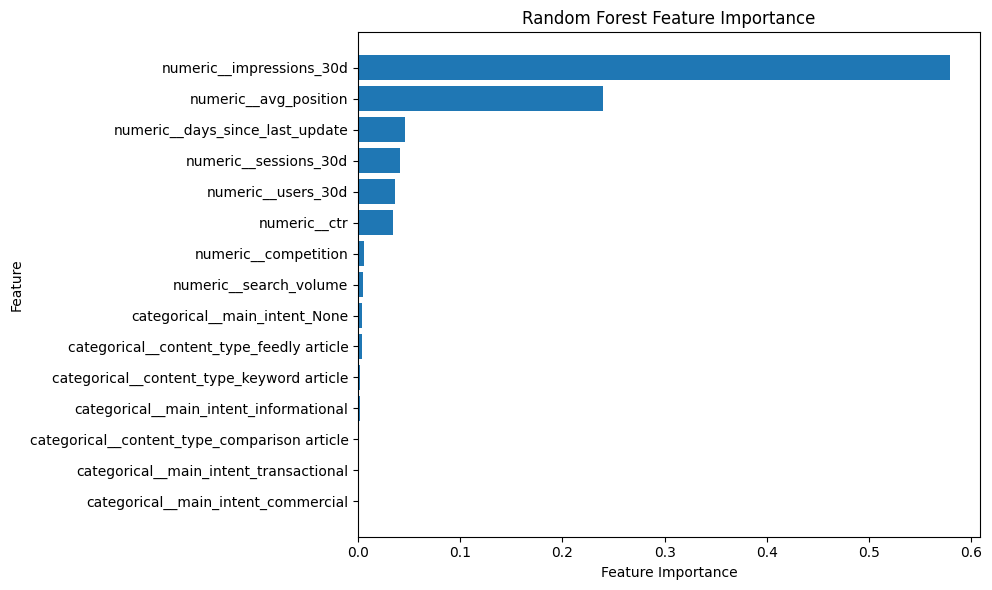

In [128]:
import matplotlib.pyplot as plt

top_features = importance_df.head(15).sort_values(
    "importance"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.tight_layout()
plt.show()

In [129]:
final_rf = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=20,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

final_rf.fit(X, y)

print("Final Random Forest trained on full dataset.")

Final Random Forest trained on full dataset.


In [130]:
all_probability = final_rf.predict_proba(X)[:, 1]

final_ranked = dataset.copy()

final_ranked["priority_score"] = all_probability

In [131]:
final_ranked = final_ranked.sort_values(
    "priority_score",
    ascending=False
).reset_index(drop=True)

final_ranked["rank"] = (
    final_ranked.index + 1
)

In [132]:
def assign_action(score):

    if score >= 0.70:
        return "HIGH_PRIORITY_REFRESH"

    elif score >= 0.50:
        return "REVIEW"

    else:
        return "MONITOR"


final_ranked["action"] = (
    final_ranked["priority_score"]
    .apply(assign_action)
)

In [133]:
display(
    final_ranked[
        [
            "rank",
            "content_hash_id",
            "priority_score",
            "action",
            "days_since_last_update",
            "impressions_30d",
            "users_30d",
            "ctr",
            "avg_position"
        ]
    ].head(20)
)

,rank,content_hash_id,priority_score,action,days_since_last_update,impressions_30d,users_30d,ctr,avg_position
0,1,content_4b949dfa6fe11f42,0.993327,HIGH_PRIORITY_REFRESH,-1,2,1,0.0,0.0
1,2,content_4a9b0ef844c27da7,0.993327,HIGH_PRIORITY_REFRESH,-1,2,1,0.0,0.0
2,3,content_4ab2a9d390cbeff2,0.993327,HIGH_PRIORITY_REFRESH,-1,2,1,0.0,0.0
3,4,content_6f43e2ee92e6a399,0.993327,HIGH_PRIORITY_REFRESH,-1,2,1,0.0,0.0
4,5,content_6f262859246cfdde,0.993327,HIGH_PRIORITY_REFRESH,-1,2,1,0.0,0.0
5,6,content_432624e53c07b53b,0.993327,HIGH_PRIORITY_REFRESH,-1,2,1,0.0,0.0
6,7,content_13e3a61d610801ad,0.993327,HIGH_PRIORITY_REFRESH,-1,2,1,0.0,0.0
7,8,content_12a5a823044a4571,0.993327,HIGH_PRIORITY_REFRESH,-1,2,1,0.0,0.0
8,9,content_141f848a975ae0db,0.993327,HIGH_PRIORITY_REFRESH,-1,2,1,0.0,0.0
9,10,content_14060cc5752c01fd,0.993327,HIGH_PRIORITY_REFRESH,-1,2,1,0.0,0.0


In [134]:
import os

os.makedirs(
    "work/outputs",
    exist_ok=True
)

final_ranked.to_csv(
    "work/outputs/final_ranked_recommendations.csv",
    index=False
)

print("Final recommendation queue saved.")

Final recommendation queue saved.


In [135]:
top20 = final_ranked.head(20).copy()

top20[
    [
        "rank",
        "content_hash_id",
        "priority_score",
        "action",
        "days_since_last_update",
        "impressions_30d",
        "users_30d",
        "ctr",
        "avg_position"
    ]
]

,rank,content_hash_id,priority_score,action,days_since_last_update,impressions_30d,users_30d,ctr,avg_position
0,1,content_4b949dfa6fe11f42,0.993327,HIGH_PRIORITY_REFRESH,-1,2,1,0.0,0.0
1,2,content_4a9b0ef844c27da7,0.993327,HIGH_PRIORITY_REFRESH,-1,2,1,0.0,0.0
2,3,content_4ab2a9d390cbeff2,0.993327,HIGH_PRIORITY_REFRESH,-1,2,1,0.0,0.0
3,4,content_6f43e2ee92e6a399,0.993327,HIGH_PRIORITY_REFRESH,-1,2,1,0.0,0.0
4,5,content_6f262859246cfdde,0.993327,HIGH_PRIORITY_REFRESH,-1,2,1,0.0,0.0
5,6,content_432624e53c07b53b,0.993327,HIGH_PRIORITY_REFRESH,-1,2,1,0.0,0.0
6,7,content_13e3a61d610801ad,0.993327,HIGH_PRIORITY_REFRESH,-1,2,1,0.0,0.0
7,8,content_12a5a823044a4571,0.993327,HIGH_PRIORITY_REFRESH,-1,2,1,0.0,0.0
8,9,content_141f848a975ae0db,0.993327,HIGH_PRIORITY_REFRESH,-1,2,1,0.0,0.0
9,10,content_14060cc5752c01fd,0.993327,HIGH_PRIORITY_REFRESH,-1,2,1,0.0,0.0


In [136]:
# Check how model score behaves across visibility levels

final_ranked["visibility_bucket"] = pd.cut(
    final_ranked["impressions_30d"],
    bins=[-1, 10, 24, 100, 500, 3000, float("inf")],
    labels=[
        "0-10",
        "11-24",
        "25-100",
        "101-500",
        "501-3000",
        "3000+"
    ]
)

visibility_check = (
    final_ranked
    .groupby("visibility_bucket", observed=False)
    .agg(
        pages=("content_hash_id", "size"),
        median_score=("priority_score", "median"),
        mean_score=("priority_score", "mean"),
        decline_rate=("decline_label", "mean"),
        median_users=("users_30d", "median"),
        median_ctr=("ctr", "median")
    )
    .reset_index()
)

display(visibility_check)

,visibility_bucket,pages,median_score,mean_score,decline_rate,median_users,median_ctr
0,0-10,210040,0.000881,0.267142,0.261255,0.0,0.000000
1,11-24,19449,0.808219,0.792817,0.767854,0.0,0.000000
2,25-100,40691,0.761850,0.741334,0.708928,0.0,0.000000
3,101-500,51772,0.726690,0.703162,0.653307,1.0,0.000000
4,501-3000,40986,0.714458,0.698414,0.665471,7.0,0.230348
5,3000+,19131,0.729359,0.704023,0.668444,26.0,0.270347


In [137]:
print(
    "Negative update age:",
    (dataset["days_since_last_update"] < 0).sum()
)

print(
    "Exactly -1:",
    (dataset["days_since_last_update"] == -1).sum()
)

Negative update age: 116431
Exactly -1: 27041


In [138]:
display(
    dataset.loc[
        dataset["days_since_last_update"] == -1,
        [
            "content_hash_id",
            "days_since_last_update",
            "impressions_30d",
            "users_30d",
            "ctr",
            "avg_position",
            "decline_label"
        ]
    ].head(20)
)

,content_hash_id,days_since_last_update,impressions_30d,users_30d,ctr,avg_position,decline_label
2,content_01efa71faea45dcc,-1,0,0,0.0,NaN,0
10,content_05ca7b257bcde136,-1,0,0,0.0,NaN,0
11,content_06696d7d02988601,-1,0,0,0.0,NaN,0
13,content_07c909efffc9e76f,-1,0,1,0.0,NaN,0
19,content_0c2a22563826d8e4,-1,0,0,0.0,NaN,0
21,content_0eaac5e6c65b446e,-1,0,0,0.0,NaN,0
27,content_0f95c65c8df0011a,-1,0,0,0.0,NaN,0
28,content_107567b5a94f1220,-1,0,0,0.0,NaN,0
42,content_153774d976242b2b,-1,0,0,0.0,NaN,0
51,content_19b5039ddf373c84,-1,0,0,0.0,NaN,0


In [139]:
final_ranked["eligible_for_refresh"] = (
    final_ranked["impressions_30d"] >= 100
)

In [140]:
def final_action(row):

    if not row["eligible_for_refresh"]:
        return "MONITOR"

    if row["priority_score"] >= 0.70:
        return "HIGH_PRIORITY_REFRESH"

    elif row["priority_score"] >= 0.50:
        return "REVIEW"

    else:
        return "MONITOR"


final_ranked["action"] = final_ranked.apply(
    final_action,
    axis=1
)

In [141]:
final_ranked = final_ranked.sort_values(
    by=["eligible_for_refresh", "priority_score", "impressions_30d"],
    ascending=[False, False, False]
).reset_index(drop=True)

final_ranked["rank"] = final_ranked.index + 1

In [142]:
display(
    final_ranked[
        [
            "rank",
            "content_hash_id",
            "priority_score",
            "action",
            "eligible_for_refresh",
            "days_since_last_update",
            "impressions_30d",
            "users_30d",
            "ctr",
            "avg_position"
        ]
    ].head(20)
)

,rank,content_hash_id,priority_score,action,eligible_for_refresh,days_since_last_update,impressions_30d,users_30d,ctr,avg_position
0,1,content_b77c09e114e0ed4c,0.970717,HIGH_PRIORITY_REFRESH,True,-32,8663,150,0.057717,36.594095
1,2,content_25de0add580222c8,0.970466,HIGH_PRIORITY_REFRESH,True,-34,6559,162,0.060985,41.539245
2,3,content_adaa4779262d136c,0.970140,HIGH_PRIORITY_REFRESH,True,95,8641,153,0.046291,40.272954
3,4,content_f98826400f5d3ad0,0.969332,HIGH_PRIORITY_REFRESH,True,-36,12007,130,0.041642,35.141468
4,5,content_d409c54a8ae8b0ab,0.968839,HIGH_PRIORITY_REFRESH,True,-34,11451,202,0.026199,36.598685
5,6,content_0e23e4ce01ea4a6d,0.968257,HIGH_PRIORITY_REFRESH,True,95,12391,130,0.008070,40.340499
6,7,content_559cdd76da9306de,0.968127,HIGH_PRIORITY_REFRESH,True,-35,13568,380,0.022111,31.680851
7,8,content_27c2b1e41448eb11,0.967827,HIGH_PRIORITY_REFRESH,True,-33,5775,130,0.034632,42.060560
8,9,content_4ee39f5889ebcee2,0.967335,HIGH_PRIORITY_REFRESH,True,95,5975,151,0.050209,36.495998
9,10,content_2172f59b2c00dfa8,0.967304,HIGH_PRIORITY_REFRESH,True,95,7754,209,0.077379,31.932649


In [143]:
def get_reason(row):

    reasons = []

    if row["impressions_30d"] >= 100:
        reasons.append("VISIBLE")

    if row["ctr"] < 0.05:
        reasons.append("LOW_CTR")

    if row["days_since_last_update"] >= 90:
        reasons.append("STALE_CONTENT")

    if row["avg_position"] > 10:
        reasons.append("WEAK_POSITION")

    if not reasons:
        return "MONITOR"

    return "_".join(reasons)


final_ranked["reason_code"] = final_ranked.apply(
    get_reason,
    axis=1
)

In [144]:
seo_queue = final_ranked[
    [
        "rank",
        "content_hash_id",
        "priority_score",
        "action",
        "reason_code",
        "days_since_last_update",
        "impressions_30d",
        "users_30d",
        "ctr",
        "avg_position"
    ]
].copy()

display(seo_queue.head(20))

,rank,content_hash_id,priority_score,action,reason_code,days_since_last_update,impressions_30d,users_30d,ctr,avg_position
0,1,content_b77c09e114e0ed4c,0.970717,HIGH_PRIORITY_REFRESH,VISIBLE_WEAK_POSITION,-32,8663,150,0.057717,36.594095
1,2,content_25de0add580222c8,0.970466,HIGH_PRIORITY_REFRESH,VISIBLE_WEAK_POSITION,-34,6559,162,0.060985,41.539245
2,3,content_adaa4779262d136c,0.970140,HIGH_PRIORITY_REFRESH,VISIBLE_LOW_CTR_STALE_CONTENT_WEAK_POSITION,95,8641,153,0.046291,40.272954
3,4,content_f98826400f5d3ad0,0.969332,HIGH_PRIORITY_REFRESH,VISIBLE_LOW_CTR_WEAK_POSITION,-36,12007,130,0.041642,35.141468
4,5,content_d409c54a8ae8b0ab,0.968839,HIGH_PRIORITY_REFRESH,VISIBLE_LOW_CTR_WEAK_POSITION,-34,11451,202,0.026199,36.598685
5,6,content_0e23e4ce01ea4a6d,0.968257,HIGH_PRIORITY_REFRESH,VISIBLE_LOW_CTR_STALE_CONTENT_WEAK_POSITION,95,12391,130,0.008070,40.340499
6,7,content_559cdd76da9306de,0.968127,HIGH_PRIORITY_REFRESH,VISIBLE_LOW_CTR_WEAK_POSITION,-35,13568,380,0.022111,31.680851
7,8,content_27c2b1e41448eb11,0.967827,HIGH_PRIORITY_REFRESH,VISIBLE_LOW_CTR_WEAK_POSITION,-33,5775,130,0.034632,42.060560
8,9,content_4ee39f5889ebcee2,0.967335,HIGH_PRIORITY_REFRESH,VISIBLE_STALE_CONTENT_WEAK_POSITION,95,5975,151,0.050209,36.495998
9,10,content_2172f59b2c00dfa8,0.967304,HIGH_PRIORITY_REFRESH,VISIBLE_STALE_CONTENT_WEAK_POSITION,95,7754,209,0.077379,31.932649


In [145]:
weak_picks = final_ranked[
    (final_ranked["action"] == "HIGH_PRIORITY_REFRESH") &
    (
        (final_ranked["impressions_30d"] < 100) |
        (final_ranked["users_30d"] < 5)
    )
]

print("Weak high-priority picks:", len(weak_picks))

display(
    weak_picks[
        [
            "content_hash_id",
            "priority_score",
            "impressions_30d",
            "users_30d",
            "ctr",
            "avg_position",
            "action"
        ]
    ].head(20)
)

Weak high-priority picks: 33950


,content_hash_id,priority_score,impressions_30d,users_30d,ctr,avg_position,action
18,content_46b5030c8e0b0cfa,0.965259,5283,0,0.283930,42.527205,HIGH_PRIORITY_REFRESH
20,content_20e2afdc1db268ac,0.965015,5273,0,0.284468,42.341521,HIGH_PRIORITY_REFRESH
21,content_b7b02476281e3ca3,0.964969,5264,0,0.284954,43.365721,HIGH_PRIORITY_REFRESH
22,content_291a8c8dc23505b1,0.964772,5284,0,0.283876,35.365144,HIGH_PRIORITY_REFRESH
24,content_d980c7495b578dbf,0.964389,5264,0,0.284954,38.181304,HIGH_PRIORITY_REFRESH
26,content_c6999e8ebf1ae7e5,0.964324,5276,0,0.284306,42.477885,HIGH_PRIORITY_REFRESH
27,content_6fe81f5c87baff9a,0.964120,5260,0,0.285171,26.067564,HIGH_PRIORITY_REFRESH
29,content_588c2c8caceb22f2,0.964070,5268,0,0.284738,45.421067,HIGH_PRIORITY_REFRESH
30,content_24ea48d6d16dce11,0.963960,5267,0,0.284792,33.341521,HIGH_PRIORITY_REFRESH
33,content_72d6da45d5878bd5,0.963828,5273,0,0.284468,42.999007,HIGH_PRIORITY_REFRESH


In [146]:
# Check available date-related columns
date_cols = [
    c for c in dataset.columns
    if "date" in c.lower() or "update" in c.lower()
]

print(date_cols)

['content_updated_date', 'content_created_date', 'days_since_last_update']


In [147]:
print(dataset[date_cols].dtypes)

content_updated_date      datetime64[us]
content_created_date      datetime64[us]
days_since_last_update             int64
dtype: object


In [148]:
negative_age = dataset[
    dataset["days_since_last_update"] < 0
].copy()

display(
    negative_age[
        date_cols + [
            "days_since_last_update",
            "impressions_30d",
            "users_30d",
            "ctr",
            "avg_position",
            "decline_label"
        ]
    ].head(20)
)

,content_updated_date,content_created_date,days_since_last_update,days_since_last_update,impressions_30d,users_30d,ctr,avg_position,decline_label
0,2026-07-01,2026-05-30,-31,-31,0,0,0.0,NaN,0
1,2026-07-01,2026-05-09,-31,-31,0,0,0.0,NaN,0
2,2026-06-01,2026-05-21,-1,-1,0,0,0.0,NaN,0
3,2026-07-01,2026-05-30,-31,-31,0,0,0.0,NaN,0
4,2026-07-01,2026-05-29,-31,-31,0,0,0.0,NaN,0
5,2026-07-01,2026-05-13,-31,-31,0,0,0.0,NaN,0
6,2026-07-01,2026-05-29,-31,-31,0,0,0.0,NaN,0
7,2026-07-01,2026-05-31,-31,-31,0,0,0.0,NaN,0
8,2026-07-01,2026-05-09,-31,-31,0,0,0.0,NaN,0
9,2026-07-01,2026-05-20,-31,-31,0,0,0.0,NaN,0


In [149]:
negative_count = (
    dataset["days_since_last_update"] < 0
).sum()

total_count = len(dataset)

print("Negative age rows:", negative_count)
print(
    "Negative age %:",
    round(negative_count / total_count * 100, 2),
    "%"
)

Negative age rows: 116431
Negative age %: 30.47 %


In [150]:
dataset["update_age_valid"] = (
    dataset["days_since_last_update"] >= 0
)

print(
    dataset["update_age_valid"].value_counts()
)

update_age_valid
True     265638
False    116431
Name: count, dtype: int64


In [151]:
dataset.groupby("update_age_valid")[
    [
        "impressions_30d",
        "users_30d",
        "ctr",
        "avg_position",
        "decline_label"
    ]
].median()

,impressions_30d,users_30d,ctr,avg_position,decline_label
update_age_valid,,,,,
False,61.0,0.0,0.0,12.068428,1.0
True,1.0,0.0,0.0,12.666667,0.0


In [152]:
print(dataset["update_age_valid"].value_counts(dropna=False))

update_age_valid
True     265638
False    116431
Name: count, dtype: int64


In [153]:
print(
    dataset.groupby("update_age_valid")[
        ["days_since_last_update", "impressions_30d", "users_30d", "ctr"]
    ].median()
)

                  days_since_last_update  impressions_30d  users_30d  ctr
update_age_valid                                                         
False                              -22.0             61.0        0.0  0.0
True                                11.0              1.0        0.0  0.0


In [154]:
invalid_updates = dataset[
    (dataset["days_since_last_update"] < 0) |
    (dataset["update_age_valid"] == False)
]

print("Invalid update-age rows:", len(invalid_updates))

display(
    invalid_updates[
        [
            "content_hash_id",
            "content_updated_date",
            "content_created_date",
            "days_since_last_update",
            "update_age_valid"
        ]
    ].head(20)
)

Invalid update-age rows: 116431


,content_hash_id,content_updated_date,content_created_date,days_since_last_update,update_age_valid
0,content_004de9653278b5a4,2026-07-01,2026-05-30,-31,False
1,content_01410f2556c327ac,2026-07-01,2026-05-09,-31,False
2,content_01efa71faea45dcc,2026-06-01,2026-05-21,-1,False
3,content_01fc9e2e57898b55,2026-07-01,2026-05-30,-31,False
4,content_0212158fa61c5fcb,2026-07-01,2026-05-29,-31,False
5,content_03d3108136ae58e9,2026-07-01,2026-05-13,-31,False
6,content_045ce5b86531f748,2026-07-01,2026-05-29,-31,False
7,content_046285d376975c21,2026-07-01,2026-05-31,-31,False
8,content_0490b0b1301d529b,2026-07-01,2026-05-09,-31,False
9,content_04b2ea44f9dcf744,2026-07-01,2026-05-20,-31,False


In [155]:
REFERENCE_DATE = pd.Timestamp("2026-06-30")

dataset["content_updated_date"] = pd.to_datetime(
    dataset["content_updated_date"],
    errors="coerce"
)

dataset["corrected_update_age"] = (
    REFERENCE_DATE - dataset["content_updated_date"]
).dt.days

print(
    "Negative corrected ages:",
    (dataset["corrected_update_age"] < 0).sum()
)

Negative corrected ages: 47365


In [156]:
display(
    dataset[
        [
            "content_updated_date",
            "days_since_last_update",
            "corrected_update_age",
            "update_age_valid"
        ]
    ].head(20)
)

,content_updated_date,days_since_last_update,corrected_update_age,update_age_valid
0,2026-07-01,-31,-1,False
1,2026-07-01,-31,-1,False
2,2026-06-01,-1,29,False
3,2026-07-01,-31,-1,False
4,2026-07-01,-31,-1,False
5,2026-07-01,-31,-1,False
6,2026-07-01,-31,-1,False
7,2026-07-01,-31,-1,False
8,2026-07-01,-31,-1,False
9,2026-07-01,-31,-1,False


In [157]:
dataset["update_age_valid_corrected"] = (
    dataset["corrected_update_age"] >= 0
)

In [158]:
print(
    dataset["update_age_valid_corrected"].value_counts()
)

update_age_valid_corrected
True     334704
False     47365
Name: count, dtype: int64


In [159]:
dataset["days_since_last_update"] = (
    dataset["corrected_update_age"]
)

In [160]:
print(
    dataset["days_since_last_update"].describe()
)

print(
    "Negative ages:",
    (dataset["days_since_last_update"] < 0).sum()
)

count    382069.000000
mean         43.642873
std          45.496160
min          -6.000000
25%          29.000000
50%          41.000000
75%          41.000000
max         394.000000
Name: days_since_last_update, dtype: float64
Negative ages: 47365


In [161]:
# Keep only pages whose update date was known on or before June 30, 2026
dataset_clean = dataset[
    dataset["corrected_update_age"] >= 0
].copy()

print("Original rows :", len(dataset))
print("Clean rows    :", len(dataset_clean))
print("Removed rows  :", len(dataset) - len(dataset_clean))

Original rows : 382069
Clean rows    : 334704
Removed rows  : 47365


In [162]:
dataset_clean["days_since_last_update"] = (
    dataset_clean["corrected_update_age"]
)

print(
    dataset_clean["days_since_last_update"].describe()
)

print(
    "Negative ages:",
    (dataset_clean["days_since_last_update"] < 0).sum()
)

count    334704.000000
mean         50.171068
std          44.930700
min           0.000000
25%          41.000000
50%          41.000000
75%          41.000000
max         394.000000
Name: days_since_last_update, dtype: float64
Negative ages: 0


In [163]:
print(
    dataset_clean["decline_label"].value_counts()
)

print(
    dataset_clean["decline_label"].value_counts(normalize=True)
)

decline_label
0    183575
1    151129
Name: count, dtype: int64
decline_label
0    0.54847
1    0.45153
Name: proportion, dtype: float64


In [164]:
numeric_features = [
    "impressions_30d",
    "users_30d",
    "sessions_30d",
    "ctr",
    "avg_position",
    "days_since_last_update",
    "search_volume",
    "competition"
]

categorical_features = [
    "content_type",
    "main_intent"
]

target = "decline_label"

In [165]:
feature_columns = numeric_features + categorical_features

X = dataset_clean[feature_columns].copy()
y = dataset_clean[target].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (334704, 10)
y shape: (334704,)


In [166]:
from sklearn.model_selection import GroupShuffleSplit

groups = dataset_clean["client_hash_id"]

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("Train:", X_train.shape)
print("Test :", X_test.shape)

print(
    "Train clients:",
    dataset_clean.iloc[train_idx]["client_hash_id"].nunique()
)

print(
    "Test clients:",
    dataset_clean.iloc[test_idx]["client_hash_id"].nunique()
)

overlap = set(
    dataset_clean.iloc[train_idx]["client_hash_id"]
).intersection(
    set(dataset_clean.iloc[test_idx]["client_hash_id"])
)

print("Client overlap:", len(overlap))

Train: (252543, 10)
Test : (82161, 10)
Train clients: 50
Test clients: 13
Client overlap: 0


In [167]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [168]:
test_probability = rf_model.predict_proba(X_test)[:, 1]

print(test_probability[:10])

[6.09816104e-06 1.91825925e-03 1.14427910e-03 8.96239342e-04
 1.14427910e-03 1.18919273e-03 1.00791132e-03 1.14427910e-03
 1.14427910e-03 1.50562080e-03]


In [169]:
import numpy as np

def precision_at_k(scores, labels, k):
    order = np.argsort(-np.asarray(scores))
    return np.asarray(labels)[order[:k]].mean()

for k in [10, 20, 50, 100]:
    score = precision_at_k(
        test_probability,
        y_test.values,
        k
    )

    print(f"Precision@{k}: {score:.3f}")

Precision@10: 0.600
Precision@20: 0.600
Precision@50: 0.640
Precision@100: 0.800


In [170]:
test_results = dataset_clean.iloc[test_idx].copy()

test_results["priority_score"] = test_probability

test_results = test_results.sort_values(
    "priority_score",
    ascending=False
).reset_index(drop=True)

test_results["rank"] = (
    test_results.index + 1
)

In [171]:
def assign_action(row):

    # Very low visibility → don't recommend immediate refresh
    if row["impressions_30d"] < 100:
        return "MONITOR"

    # Strong predicted decline + meaningful visibility
    if row["priority_score"] >= 0.70:
        return "HIGH_PRIORITY_REFRESH"

    # Moderate predicted decline
    elif row["priority_score"] >= 0.55:
        return "REVIEW"

    else:
        return "MONITOR"


test_results["action"] = test_results.apply(
    assign_action,
    axis=1
)

In [172]:
display(
    test_results[
        [
            "rank",
            "content_hash_id",
            "priority_score",
            "action",
            "days_since_last_update",
            "impressions_30d",
            "users_30d",
            "ctr",
            "avg_position"
        ]
    ].head(20)
)

,rank,content_hash_id,priority_score,action,days_since_last_update,impressions_30d,users_30d,ctr,avg_position
0,1,content_c7555ca1424964bc,0.902990,HIGH_PRIORITY_REFRESH,46,2525,28,0.118812,24.197071
1,2,content_a5d8f97d3db1391b,0.894715,MONITOR,41,1,1,0.000000,0.000000
2,3,content_32cdd791ebbbd611,0.894582,HIGH_PRIORITY_REFRESH,8,5853,76,0.051256,10.840980
3,4,content_6c3e8337a174b460,0.892402,HIGH_PRIORITY_REFRESH,46,1525,31,0.131148,33.536233
4,5,content_b58250fff73d132f,0.892325,MONITOR,41,1,0,0.000000,0.000000
5,6,content_2dc599bd26a93d22,0.890917,MONITOR,41,1,0,0.000000,0.000000
6,7,content_feaa97bcdab06a2e,0.887278,HIGH_PRIORITY_REFRESH,46,2049,20,0.146413,30.203111
7,8,content_017fce5a57cdf719,0.884202,HIGH_PRIORITY_REFRESH,46,1870,17,0.000000,24.209409
8,9,content_f49650d3f12232a5,0.881836,MONITOR,41,1,0,0.000000,0.000000
9,10,content_f349960becc9015a,0.880627,HIGH_PRIORITY_REFRESH,46,1404,15,0.071225,21.018752


In [173]:
baseline_test = dataset_clean.iloc[test_idx].copy()

baseline_test["baseline_score"] = 0

# Meaningful visibility
baseline_test.loc[
    baseline_test["impressions_30d"] >= 24,
    "baseline_score"
] += 2

# CTR opportunity
baseline_test.loc[
    (baseline_test["ctr"] >= 0.05) &
    (baseline_test["ctr"] < 0.20),
    "baseline_score"
] += 3

# Staleness
baseline_test.loc[
    baseline_test["days_since_last_update"] >= 90,
    "baseline_score"
] += 2

baseline_test = baseline_test.sort_values(
    ["baseline_score", "impressions_30d"],
    ascending=[False, False]
).reset_index(drop=True)

In [174]:
comparison = []

for k in [10, 20, 50, 100]:

    baseline_precision = (
        baseline_test.head(k)["decline_label"].mean()
    )

    model_precision = precision_at_k(
        test_probability,
        y_test.values,
        k
    )

    comparison.append({
        "K": k,
        "Baseline": baseline_precision,
        "Random_Forest": model_precision,
        "Improvement": model_precision - baseline_precision
    })

comparison_df = pd.DataFrame(comparison)

display(comparison_df)

,K,Baseline,Random_Forest,Improvement
0,10,0.90,0.60,-0.30
1,20,0.85,0.60,-0.25
2,50,0.78,0.64,-0.14
3,100,0.72,0.80,0.08


In [175]:
rf = rf_model.named_steps["model"]
prep = rf_model.named_steps["preprocessor"]

feature_names = prep.get_feature_names_out()

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": rf.feature_importances_
})

importance_df = importance_df.sort_values(
    "importance",
    ascending=False
).reset_index(drop=True)

display(importance_df.head(20))

,feature,importance
0,numeric__impressions_30d,0.565367
1,numeric__avg_position,0.247332
2,numeric__days_since_last_update,0.052336
3,numeric__ctr,0.036878
4,numeric__sessions_30d,0.032474
5,numeric__users_30d,0.032428
6,categorical__main_intent_None,0.006280
7,numeric__search_volume,0.005518
8,categorical__content_type_feedly article,0.005418
9,numeric__competition,0.005156


In [176]:
display(
    test_results[
        [
            "rank",
            "content_hash_id",
            "priority_score",
            "action",
            "days_since_last_update",
            "impressions_30d",
            "users_30d",
            "ctr",
            "avg_position"
        ]
    ].head(20)
)

,rank,content_hash_id,priority_score,action,days_since_last_update,impressions_30d,users_30d,ctr,avg_position
0,1,content_c7555ca1424964bc,0.902990,HIGH_PRIORITY_REFRESH,46,2525,28,0.118812,24.197071
1,2,content_a5d8f97d3db1391b,0.894715,MONITOR,41,1,1,0.000000,0.000000
2,3,content_32cdd791ebbbd611,0.894582,HIGH_PRIORITY_REFRESH,8,5853,76,0.051256,10.840980
3,4,content_6c3e8337a174b460,0.892402,HIGH_PRIORITY_REFRESH,46,1525,31,0.131148,33.536233
4,5,content_b58250fff73d132f,0.892325,MONITOR,41,1,0,0.000000,0.000000
5,6,content_2dc599bd26a93d22,0.890917,MONITOR,41,1,0,0.000000,0.000000
6,7,content_feaa97bcdab06a2e,0.887278,HIGH_PRIORITY_REFRESH,46,2049,20,0.146413,30.203111
7,8,content_017fce5a57cdf719,0.884202,HIGH_PRIORITY_REFRESH,46,1870,17,0.000000,24.209409
8,9,content_f49650d3f12232a5,0.881836,MONITOR,41,1,0,0.000000,0.000000
9,10,content_f349960becc9015a,0.880627,HIGH_PRIORITY_REFRESH,46,1404,15,0.071225,21.018752


In [177]:
print(
    "Top-20 low visibility pages:",
    (
        test_results.head(20)["impressions_30d"] < 100
    ).sum()
)

Top-20 low visibility pages: 12


In [178]:
def get_reason(row):

    reasons = []

    if row["impressions_30d"] >= 100:
        reasons.append("VISIBLE")

    if row["days_since_last_update"] >= 90:
        reasons.append("STALE")

    if row["ctr"] < 0.20:
        reasons.append("LOW_CTR")

    if row["avg_position"] > 10:
        reasons.append("LOW_POSITION")

    if len(reasons) == 0:
        return "LOW_SIGNAL"

    return "_".join(reasons)


test_results["reason_code"] = test_results.apply(
    get_reason,
    axis=1
)

In [179]:
display(
    test_results[
        [
            "rank",
            "content_hash_id",
            "priority_score",
            "action",
            "reason_code",
            "days_since_last_update",
            "impressions_30d",
            "users_30d",
            "ctr",
            "avg_position"
        ]
    ].head(20)
)

,rank,content_hash_id,priority_score,action,reason_code,days_since_last_update,impressions_30d,users_30d,ctr,avg_position
0,1,content_c7555ca1424964bc,0.902990,HIGH_PRIORITY_REFRESH,VISIBLE_LOW_CTR_LOW_POSITION,46,2525,28,0.118812,24.197071
1,2,content_a5d8f97d3db1391b,0.894715,MONITOR,LOW_CTR,41,1,1,0.000000,0.000000
2,3,content_32cdd791ebbbd611,0.894582,HIGH_PRIORITY_REFRESH,VISIBLE_LOW_CTR_LOW_POSITION,8,5853,76,0.051256,10.840980
3,4,content_6c3e8337a174b460,0.892402,HIGH_PRIORITY_REFRESH,VISIBLE_LOW_CTR_LOW_POSITION,46,1525,31,0.131148,33.536233
4,5,content_b58250fff73d132f,0.892325,MONITOR,LOW_CTR,41,1,0,0.000000,0.000000
5,6,content_2dc599bd26a93d22,0.890917,MONITOR,LOW_CTR,41,1,0,0.000000,0.000000
6,7,content_feaa97bcdab06a2e,0.887278,HIGH_PRIORITY_REFRESH,VISIBLE_LOW_CTR_LOW_POSITION,46,2049,20,0.146413,30.203111
7,8,content_017fce5a57cdf719,0.884202,HIGH_PRIORITY_REFRESH,VISIBLE_LOW_CTR_LOW_POSITION,46,1870,17,0.000000,24.209409
8,9,content_f49650d3f12232a5,0.881836,MONITOR,LOW_CTR,41,1,0,0.000000,0.000000
9,10,content_f349960becc9015a,0.880627,HIGH_PRIORITY_REFRESH,VISIBLE_LOW_CTR_LOW_POSITION,46,1404,15,0.071225,21.018752


In [180]:
final_recommendations = test_results[
    [
        "rank",
        "content_hash_id",
        "priority_score",
        "action",
        "reason_code",
        "days_since_last_update",
        "impressions_30d",
        "users_30d",
        "ctr",
        "avg_position"
    ]
].copy()

display(final_recommendations.head(20))

,rank,content_hash_id,priority_score,action,reason_code,days_since_last_update,impressions_30d,users_30d,ctr,avg_position
0,1,content_c7555ca1424964bc,0.902990,HIGH_PRIORITY_REFRESH,VISIBLE_LOW_CTR_LOW_POSITION,46,2525,28,0.118812,24.197071
1,2,content_a5d8f97d3db1391b,0.894715,MONITOR,LOW_CTR,41,1,1,0.000000,0.000000
2,3,content_32cdd791ebbbd611,0.894582,HIGH_PRIORITY_REFRESH,VISIBLE_LOW_CTR_LOW_POSITION,8,5853,76,0.051256,10.840980
3,4,content_6c3e8337a174b460,0.892402,HIGH_PRIORITY_REFRESH,VISIBLE_LOW_CTR_LOW_POSITION,46,1525,31,0.131148,33.536233
4,5,content_b58250fff73d132f,0.892325,MONITOR,LOW_CTR,41,1,0,0.000000,0.000000
5,6,content_2dc599bd26a93d22,0.890917,MONITOR,LOW_CTR,41,1,0,0.000000,0.000000
6,7,content_feaa97bcdab06a2e,0.887278,HIGH_PRIORITY_REFRESH,VISIBLE_LOW_CTR_LOW_POSITION,46,2049,20,0.146413,30.203111
7,8,content_017fce5a57cdf719,0.884202,HIGH_PRIORITY_REFRESH,VISIBLE_LOW_CTR_LOW_POSITION,46,1870,17,0.000000,24.209409
8,9,content_f49650d3f12232a5,0.881836,MONITOR,LOW_CTR,41,1,0,0.000000,0.000000
9,10,content_f349960becc9015a,0.880627,HIGH_PRIORITY_REFRESH,VISIBLE_LOW_CTR_LOW_POSITION,46,1404,15,0.071225,21.018752


In [181]:
# Pages with meaningful search visibility are eligible
# for refresh prioritization.

eligible_results = test_results[
    test_results["impressions_30d"] >= 100
].copy()

print("Total test pages:", len(test_results))
print("Eligible pages:", len(eligible_results))
print(
    "Excluded low-visibility pages:",
    len(test_results) - len(eligible_results)
)

Total test pages: 82161
Eligible pages: 18479
Excluded low-visibility pages: 63682


In [182]:
eligible_results = eligible_results.sort_values(
    "priority_score",
    ascending=False
).reset_index(drop=True)

eligible_results["rank"] = (
    eligible_results.index + 1
)

In [183]:
def final_action(row):

    if row["priority_score"] >= 0.70:
        return "HIGH_PRIORITY_REFRESH"

    elif row["priority_score"] >= 0.55:
        return "REVIEW"

    else:
        return "MONITOR"


eligible_results["action"] = eligible_results.apply(
    final_action,
    axis=1
)

In [184]:
def final_reason(row):

    reasons = []

    if row["impressions_30d"] >= 100:
        reasons.append("VISIBLE")

    if row["days_since_last_update"] >= 90:
        reasons.append("STALE")

    if row["ctr"] < 0.20:
        reasons.append("LOW_CTR")

    if row["avg_position"] > 10:
        reasons.append("LOW_POSITION")

    if not reasons:
        return "LOW_SIGNAL"

    return "_".join(reasons)


eligible_results["reason_code"] = eligible_results.apply(
    final_reason,
    axis=1
)

In [185]:
final_top20 = eligible_results[
    [
        "rank",
        "content_hash_id",
        "priority_score",
        "action",
        "reason_code",
        "days_since_last_update",
        "impressions_30d",
        "users_30d",
        "ctr",
        "avg_position"
    ]
].head(20)

display(final_top20)

,rank,content_hash_id,priority_score,action,reason_code,days_since_last_update,impressions_30d,users_30d,ctr,avg_position
0,1,content_c7555ca1424964bc,0.902990,HIGH_PRIORITY_REFRESH,VISIBLE_LOW_CTR_LOW_POSITION,46,2525,28,0.118812,24.197071
1,2,content_32cdd791ebbbd611,0.894582,HIGH_PRIORITY_REFRESH,VISIBLE_LOW_CTR_LOW_POSITION,8,5853,76,0.051256,10.840980
2,3,content_6c3e8337a174b460,0.892402,HIGH_PRIORITY_REFRESH,VISIBLE_LOW_CTR_LOW_POSITION,46,1525,31,0.131148,33.536233
3,4,content_feaa97bcdab06a2e,0.887278,HIGH_PRIORITY_REFRESH,VISIBLE_LOW_CTR_LOW_POSITION,46,2049,20,0.146413,30.203111
4,5,content_017fce5a57cdf719,0.884202,HIGH_PRIORITY_REFRESH,VISIBLE_LOW_CTR_LOW_POSITION,46,1870,17,0.000000,24.209409
5,6,content_f349960becc9015a,0.880627,HIGH_PRIORITY_REFRESH,VISIBLE_LOW_CTR_LOW_POSITION,46,1404,15,0.071225,21.018752
6,7,content_c49e43d3d29f7569,0.876681,HIGH_PRIORITY_REFRESH,VISIBLE_LOW_CTR_LOW_POSITION,46,1884,14,0.159236,14.596378
7,8,content_8fdf07060434bd49,0.876521,HIGH_PRIORITY_REFRESH,VISIBLE_LOW_POSITION,46,1479,27,0.270453,17.214409
8,9,content_1d0bcb4143973a2c,0.874329,HIGH_PRIORITY_REFRESH,VISIBLE_LOW_CTR_LOW_POSITION,46,1785,14,0.168067,21.124919
9,10,content_62460a440bdf0f11,0.873572,HIGH_PRIORITY_REFRESH,VISIBLE_LOW_POSITION,18,11791,59,0.390128,32.948010


In [186]:
print(
    eligible_results["action"].value_counts()
)

action
REVIEW                   7968
MONITOR                  6873
HIGH_PRIORITY_REFRESH    3638
Name: count, dtype: int64


In [187]:
print(
    eligible_results["reason_code"].value_counts().head(20)
)

reason_code
VISIBLE_LOW_CTR_LOW_POSITION          7978
VISIBLE_LOW_POSITION                  5868
VISIBLE                               2630
VISIBLE_LOW_CTR                        970
VISIBLE_STALE_LOW_CTR_LOW_POSITION     543
VISIBLE_STALE_LOW_POSITION             346
VISIBLE_STALE                          111
VISIBLE_STALE_LOW_CTR                   33
Name: count, dtype: int64


In [188]:
eligible_labels = eligible_results["decline_label"].values
eligible_scores = eligible_results["priority_score"].values

for k in [10, 20, 50, 100]:

    score = precision_at_k(
        eligible_scores,
        eligible_labels,
        k
    )

    print(
        f"Eligible Precision@{k}: {score:.3f}"
    )

Eligible Precision@10: 0.300
Eligible Precision@20: 0.300
Eligible Precision@50: 0.440
Eligible Precision@100: 0.530


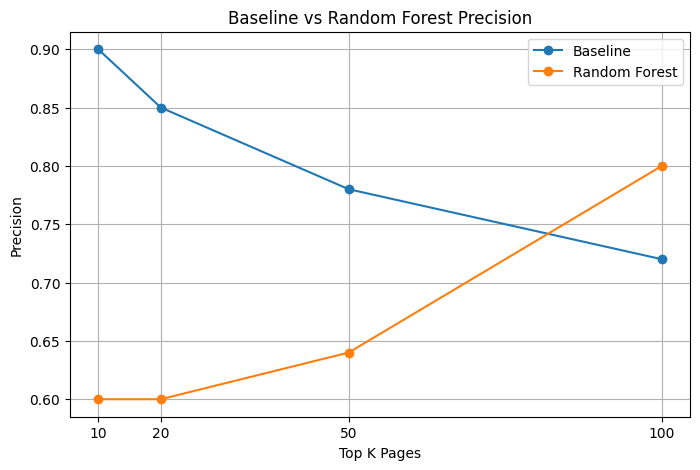

In [189]:
import matplotlib.pyplot as plt

comparison_plot = comparison_df.copy()

x = comparison_plot["K"]

plt.figure(figsize=(8, 5))

plt.plot(
    x,
    comparison_plot["Baseline"],
    marker="o",
    label="Baseline"
)

plt.plot(
    x,
    comparison_plot["Random_Forest"],
    marker="o",
    label="Random Forest"
)

plt.xlabel("Top K Pages")
plt.ylabel("Precision")
plt.title("Baseline vs Random Forest Precision")
plt.xticks(x)
plt.legend()
plt.grid(True)

plt.show()

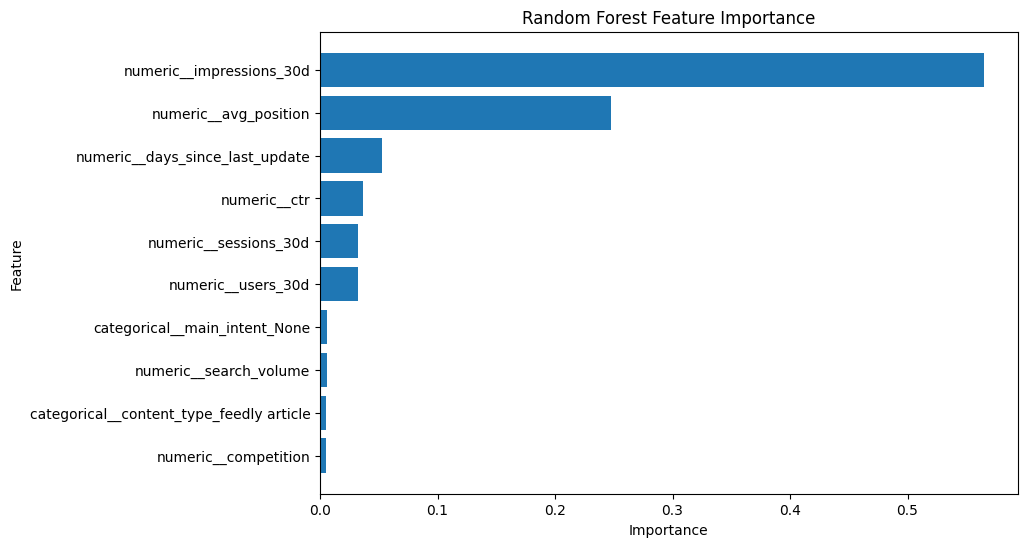

In [190]:
top_features = importance_df.head(10).sort_values(
    "importance"
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.show()

In [191]:
model_features = (
    numeric_features +
    categorical_features
)

print("Model features:")
print(model_features)

Model features:
['impressions_30d', 'users_30d', 'sessions_30d', 'ctr', 'avg_position', 'days_since_last_update', 'search_volume', 'competition', 'content_type', 'main_intent']


In [192]:
print("Final rows:", len(eligible_results))

print(
    "Negative update ages:",
    (eligible_results["days_since_last_update"] < 0).sum()
)

print(
    "Low visibility pages:",
    (eligible_results["impressions_30d"] < 100).sum()
)

print(
    "Duplicate content IDs:",
    eligible_results["content_hash_id"].duplicated().sum()
)

Final rows: 18479
Negative update ages: 0
Low visibility pages: 0
Duplicate content IDs: 0


In [193]:
import os

os.makedirs("work/outputs", exist_ok=True)

final_output = eligible_results[
    [
        "rank",
        "content_hash_id",
        "priority_score",
        "action",
        "reason_code",
        "days_since_last_update",
        "impressions_30d",
        "users_30d",
        "ctr",
        "avg_position"
    ]
]

final_output.to_csv(
    "work/outputs/final_refresh_recommendations.csv",
    index=False
)

print(
    "Saved: work/outputs/final_refresh_recommendations.csv"
)

Saved: work/outputs/final_refresh_recommendations.csv


In [194]:
final_top20.to_csv(
    "work/outputs/top20_refresh_recommendations.csv",
    index=False
)

print("Top-20 recommendations saved.")

Top-20 recommendations saved.


In [195]:
print("========== FINAL CAPSTONE RESULTS ==========")

print(
    "Baseline Precision@10:",
    comparison_df.loc[
        comparison_df["K"] == 10,
        "Baseline"
    ].iloc[0]
)

print(
    "RF Precision@10:",
    comparison_df.loc[
        comparison_df["K"] == 10,
        "Random_Forest"
    ].iloc[0]
)

print(
    "Baseline Precision@20:",
    comparison_df.loc[
        comparison_df["K"] == 20,
        "Baseline"
    ].iloc[0]
)

print(
    "RF Precision@20:",
    comparison_df.loc[
        comparison_df["K"] == 20,
        "Random_Forest"
    ].iloc[0]
)

print(
    "Baseline Precision@50:",
    comparison_df.loc[
        comparison_df["K"] == 50,
        "Baseline"
    ].iloc[0]
)

print(
    "RF Precision@50:",
    comparison_df.loc[
        comparison_df["K"] == 50,
        "Random_Forest"
    ].iloc[0]
)

print(
    "Baseline Precision@100:",
    comparison_df.loc[
        comparison_df["K"] == 100,
        "Baseline"
    ].iloc[0]
)

print(
    "RF Precision@100:",
    comparison_df.loc[
        comparison_df["K"] == 100,
        "Random_Forest"
    ].iloc[0]
)

========== FINAL CAPSTONE RESULTS ==========
Baseline Precision@10: 0.9
RF Precision@10: 0.6
Baseline Precision@20: 0.85
RF Precision@20: 0.6
Baseline Precision@50: 0.78
RF Precision@50: 0.64
Baseline Precision@100: 0.72
RF Precision@100: 0.8


In [196]:
eligible_results = test_results[
    test_results["impressions_30d"] >= 100
].copy()

print(len(eligible_results))

18479


In [197]:
eligible_results = eligible_results.sort_values(
    "priority_score",
    ascending=False
).reset_index(drop=True)

eligible_results["rank"] = eligible_results.index + 1

In [198]:
eligible_results["action"] = eligible_results.apply(
    final_action,
    axis=1
)

eligible_results["reason_code"] = eligible_results.apply(
    final_reason,
    axis=1
)

In [199]:
eligible_results[
    [
        "rank",
        "content_hash_id",
        "priority_score",
        "action",
        "reason_code",
        "days_since_last_update",
        "impressions_30d",
        "users_30d",
        "ctr",
        "avg_position"
    ]
].to_csv(
    "work/outputs/final_refresh_recommendations.csv",
    index=False
)

print("FINAL CAPSTONE OUTPUT SAVED")

FINAL CAPSTONE OUTPUT SAVED
